In [1]:
from collections.abc import Sequence
import itertools
from itertools import chain, combinations
from json import load
import os
import sys

sys.path.append(os.path.abspath('../src'))

import catboost

import joblib
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks,\
                                plot, margins
import numpy as np
import polars as pl
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score,\
                            confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm

from feature_extractor import FeatureExtractor

In [2]:
SEED = 42


In [3]:
dataset = pl.read_csv(
    '../data/processed/train.csv'
    )


# Приготовления

## Разбиение на фолды

In [4]:
stratified_k_fold = StratifiedKFold(n_splits=5,
                                    random_state=SEED,
                                    shuffle=True)

big_X_raw = dataset.drop('error_type_label')
big_y_raw = dataset['error_type_label']

for _, val_indices in stratified_k_fold.split(
                                        np.zeros(dataset.height),
                                        big_y_raw):
    display(big_y_raw[val_indices]\
            .value_counts()\
            .sort('count', descending=True))
                                        

error_type_label,count
i64,u32
0,2967
4,173
3,62
7,51
6,28
2,19
5,11
1,4


error_type_label,count
i64,u32
0,2966
4,173
3,62
7,50
6,28
2,19
5,12
1,5


error_type_label,count
i64,u32
0,2966
4,173
3,62
7,51
6,27
2,19
5,12
1,5


error_type_label,count
i64,u32
0,2966
4,173
3,62
7,51
6,28
2,18
5,12
1,5


error_type_label,count
i64,u32
0,2966
4,173
3,62
7,51
6,28
2,18
5,12
1,5


In [5]:
stratified_k_fold = StratifiedKFold(n_splits=5,
                                    random_state=SEED,
                                    shuffle=True)

feature_extractor = FeatureExtractor(
    stop_words=('нрзб',),
    search_stop_words=('это',),
    word_list_n_candidates=200,
    word_list_radius=10,
    ruwordnet_n_candidates=200,
    ruwordnet_n_best=10
)

big_X_raw = dataset.drop('error_type_label')
big_y_raw = dataset['error_type_label']

folds_train: list[tuple[pl.DataFrame, pl.Series]] = []
folds_val: list[tuple[pl.DataFrame, pl.Series]] = []

for train_indices, val_indices in stratified_k_fold.split(
                                        np.zeros(dataset.height),
                                        big_y_raw):
    folds_train.append((
        feature_extractor.fit_transform(big_X_raw[train_indices]),
        big_y_raw[train_indices]
    ))
    folds_val.append((
        feature_extractor.transform(big_X_raw[val_indices]),
        big_y_raw[val_indices]
    ))
    assert (folds_train[-1][0].sum_horizontal().sum() * 0) == 0
    assert (folds_train[-1][0].null_count().sum_horizontal().sum()) == 0


1462it [00:24, 59.26it/s]
702it [00:09, 72.61it/s]
1448it [00:25, 56.85it/s]
679it [00:10, 65.91it/s]
1450it [00:30, 47.29it/s]
698it [00:13, 52.76it/s]
1444it [00:32, 44.97it/s]
697it [00:13, 52.88it/s]
1461it [00:26, 55.31it/s]
697it [00:08, 78.06it/s]


In [6]:
joblib.dump((folds_train, folds_val), 'features.joblib.xz', 9)


['features.joblib.xz']

In [3]:
folds_train, folds_val = joblib.load('features.joblib.xz')


## Функция для оценивания

In [4]:
error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


In [5]:
def evaluate(model: BaseEstimator,
    folds_train: list[tuple[pl.DataFrame, pl.Series]] = folds_train,
    folds_val: list[tuple[pl.DataFrame, pl.Series]] = folds_val,
    error_type_ids_to_names: list[str] = error_type_ids_to_names,
    *,
    include_classes: set[int] | None = None,
    merge_classes: list[int] | None = None,
    merge_classes_names: list[str] | None = None,
    supress_plot: bool = False,
    supress_print: bool = False,
    include_features: list[str] | None = None,
    exclude_features: list[str] | None = None,
    output_separate_f1s: bool = False):

    assert len(folds_train) == len(folds_val)
    number_of_folds: int = len(folds_train)
    classes_present: set[int] = {
                                   label 
                                   for _, y_val in folds_val 
                                   for label in y_val.unique().to_list()
                                }
    
    if include_classes:
        classes_present &= include_classes
    else:
        include_classes = classes_present

    if merge_classes:
        classes_present = {merge_classes[class_]
                           for class_ in classes_present}
        if merge_classes_names:
            error_type_ids_to_names = merge_classes_names
        else:
            error_type_ids_to_names = [f'Класс {i}'
                                for i
                                in range(len(error_type_ids_to_names))]
    else:
        merge_classes = [-1] * (max(classes_present) + 1)
        for class_ in classes_present:
            merge_classes[class_] = class_

    classes_present_names: list[str] = [error_type_ids_to_names[i]
                                        for i in classes_present]
    number_of_classes: int = len(classes_present)

    f1s = np.zeros((number_of_folds, number_of_classes))
    precisions = f1s.copy()
    recalls = f1s.copy()
    confusion_matrices = np.zeros((number_of_folds,
                                   number_of_classes, 
                                   number_of_classes))
    
    for i, (fold_train, fold_val)\
                        in tqdm(enumerate(zip(folds_train, folds_val)), 
                                disable=supress_print):
        X_train, y_train = fold_train
        train_mask = y_train.is_in(include_classes)
        X_train, y_train = X_train.filter(train_mask),\
                                        y_train.filter(train_mask)
        y_train = pl.Series(merge_classes).gather(y_train)
        if include_features:
            X_train = X_train.select(
                pl.col(*include_features)
            )
        if exclude_features:
            X_train = X_train.select(
                pl.exclude(*exclude_features)
            )
        model.fit(X_train, y_train)

        X_val, y_val = fold_val
        val_mask = y_val.is_in(include_classes)
        X_val, y_val = X_val.filter(val_mask), y_val.filter(val_mask)
        y_val = pl.Series(merge_classes).gather(y_val)
        if include_features:
            X_val = X_val.select(
                pl.col(*include_features)
            )
        if exclude_features:
            X_val = X_val.select(
                pl.exclude(*exclude_features)
            )
        predictions = model.predict(X_val)

        precisions[i] = precision_score(y_val, predictions,
                                         average=None,
                                                zero_division=0)
        recalls[i] = recall_score(y_val, predictions, average=None,
                                                zero_division=0)
        f1s[i] = f1_score(y_val, predictions, average=None,
                                                zero_division=0)
        confusion_matrices[i] = confusion_matrix(y_val, predictions,
                                                 normalize='true')
        
    np.set_printoptions(suppress=True)

    if not supress_print:
        print('Класс\t\t\tPrecision\tRecall\t\tF1')
        print(*('%s%.2f±%.2f\t%.2f±%.2f\t%.2f±%.2f' % (f'{name:<24}',
                precision_m.item(),
                precision_s.item(),
                recall_m.item(),
                recall_s.item(),
                f1_m.item(),
                f1_s.item())
                for name, precision_m, precision_s,
                        recall_m, recall_s, 
                        f1_m, f1_s
                in zip(classes_present_names,
                    precisions.mean(axis=0),
                    precisions.std(axis=0),
                    recalls.mean(axis=0),
                    recalls.std(axis=0),
                    f1s.mean(axis=0),
                    f1s.std(axis=0))), 
                sep='\n')
        print('%s%.2f±%.2f\t%.2f±%.2f\t%.2f±%.2f' % (f'{'По всем':<24}',
                precisions.mean(axis=1).mean(),
                precisions.std(axis=1).std(),
                recalls.mean(axis=1).mean(),
                recalls.std(axis=1).std(),
                f1s.mean(axis=1).mean(),
                f1s.mean(axis=1).std()))
    
    if not supress_plot:
        imshow(confusion_matrices.mean(axis=0))
        ylabel('Истина')
        xlabel('Предсказание')
        yticks(range(number_of_classes), classes_present_names)
        xticks(range(number_of_classes), classes_present_names, 
            rotation=45)

    if output_separate_f1s:
        return f1s.mean(axis=0)
    return f1s.mean(axis=1).mean()


### Проверка функции для оценивания

0it [00:00, ?it/s]

5it [00:07,  1.58s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.82±0.16	0.76±0.23	0.76±0.16
аномия                  0.75±0.06	0.72±0.12	0.73±0.08
дизартрия               0.35±0.03	0.15±0.04	0.21±0.05
задержка                0.69±0.04	0.39±0.03	0.50±0.01
поиск слова             0.50±0.15	0.34±0.14	0.40±0.14
семантическая парафазия 0.45±0.11	0.28±0.04	0.34±0.06
фонетическая парафазия  0.62±0.06	0.41±0.06	0.49±0.05
По всем                 0.64±0.01	0.50±0.02	0.55±0.02


np.float64(0.5485709229817121)

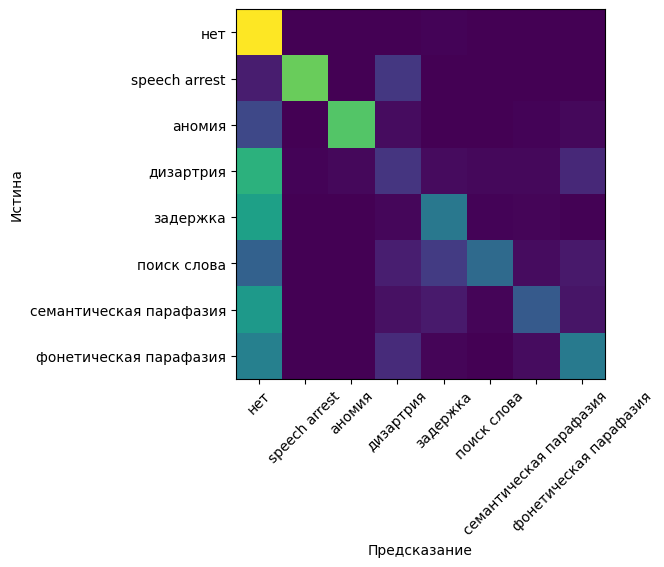

In [9]:
evaluate(DecisionTreeClassifier(max_depth=10))


5it [00:05,  1.10s/it]

Класс			Precision	Recall		F1
нет                     0.97±0.00	0.99±0.00	0.98±0.00
задержка                0.67±0.05	0.40±0.03	0.50±0.03
По всем                 0.82±0.03	0.69±0.02	0.74±0.02


np.float64(0.7387808695073058)

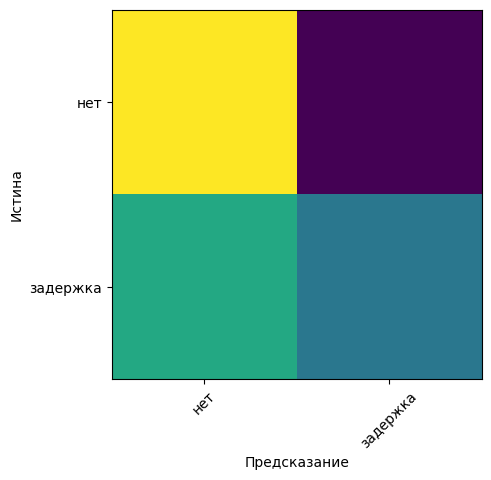

In [10]:
evaluate(DecisionTreeClassifier(max_depth=10), include_classes={0,4})


5it [00:04,  1.13it/s]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.98±0.00	0.96±0.00
есть                    0.77±0.02	0.51±0.02	0.61±0.01
По всем                 0.86±0.01	0.75±0.01	0.79±0.01


np.float64(0.7880604791351289)

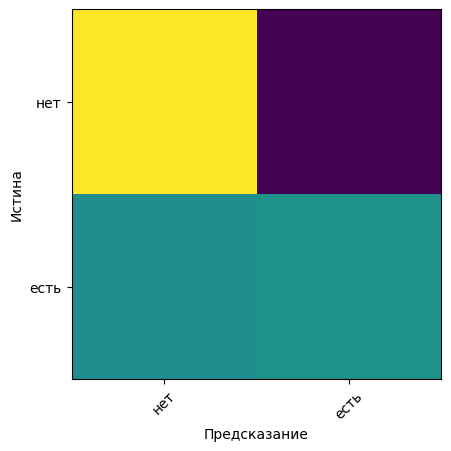

In [11]:
evaluate(DecisionTreeClassifier(max_depth=10, random_state=SEED),
         merge_classes=[0,1,1,1,1,1,1,1],
         merge_classes_names=['нет', 'есть'])


5it [00:05,  1.03s/it]

Класс			Precision	Recall		F1
Класс 0                 0.94±0.00	0.98±0.00	0.96±0.00
Класс 1                 0.77±0.02	0.51±0.02	0.61±0.01
По всем                 0.86±0.01	0.75±0.01	0.79±0.01


np.float64(0.7880604791351289)

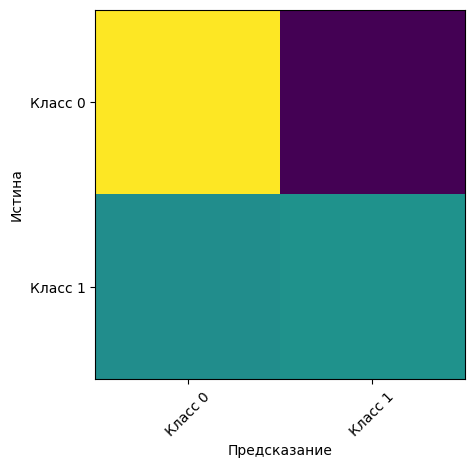

In [12]:
evaluate(DecisionTreeClassifier(max_depth=10, random_state=SEED),
         merge_classes=[0,1,1,1,1,1,1,1])


5it [00:04,  1.07it/s]

Класс			Precision	Recall		F1
нет                     0.90±0.00	1.00±0.00	0.95±0.00
speech arrest           0.00±0.00	0.00±0.00	0.00±0.00
аномия                  0.79±0.17	0.40±0.07	0.53±0.09
дизартрия               0.43±0.39	0.01±0.01	0.02±0.02
задержка                0.00±0.00	0.00±0.00	0.00±0.00
поиск слова             0.00±0.00	0.00±0.00	0.00±0.00
семантическая парафазия 0.78±0.22	0.12±0.03	0.21±0.05
фонетическая парафазия  0.70±0.18	0.09±0.04	0.15±0.06
По всем                 0.45±0.02	0.20±0.01	0.23±0.02


np.float64(0.23211170926659644)

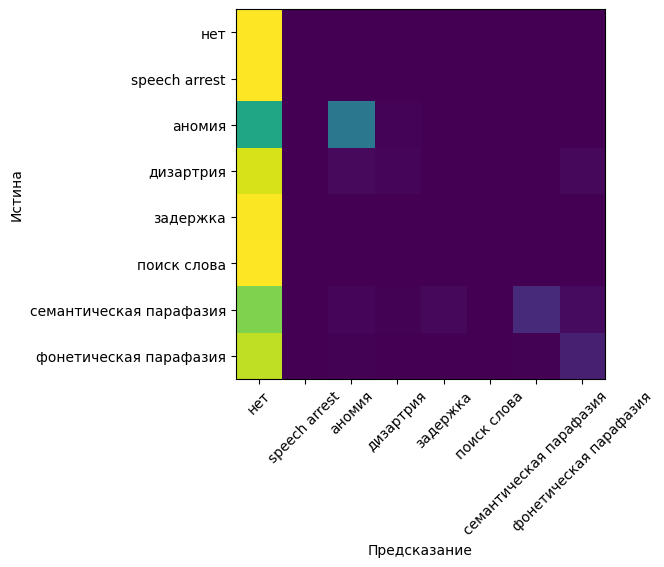

In [13]:
evaluate(DecisionTreeClassifier(max_depth=10),
         include_features=['^.+[а-яё ].+$'])

5it [00:05,  1.01s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.83±0.15	0.63±0.19	0.69±0.14
аномия                  0.74±0.09	0.69±0.11	0.71±0.08
дизартрия               0.37±0.03	0.16±0.03	0.23±0.03
задержка                0.69±0.04	0.41±0.03	0.51±0.02
поиск слова             0.63±0.12	0.41±0.02	0.49±0.03
семантическая парафазия 0.49±0.11	0.29±0.04	0.37±0.06
фонетическая парафазия  0.63±0.08	0.41±0.07	0.49±0.05
По всем                 0.66±0.03	0.50±0.01	0.56±0.01


np.float64(0.5552214186119796)

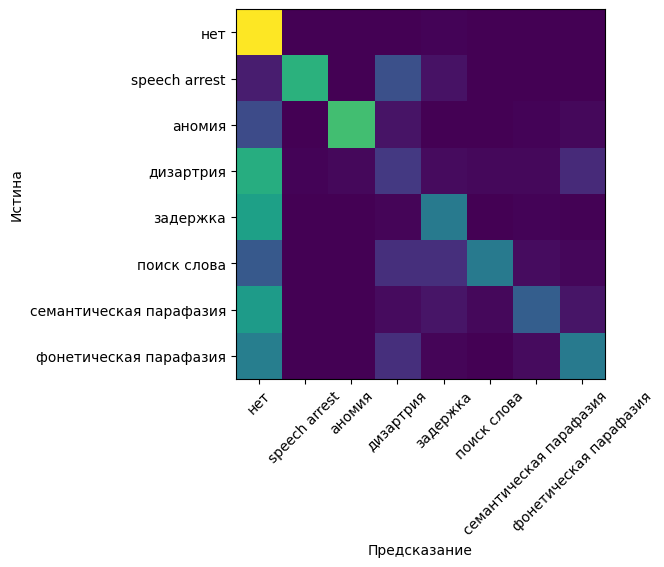

In [14]:
evaluate(DecisionTreeClassifier(max_depth=10),
         include_features=['^.+[^а-яё ].+$'])


5it [00:05,  1.15s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.82±0.16	0.71±0.20	0.73±0.12
аномия                  0.78±0.06	0.70±0.11	0.73±0.06
дизартрия               0.37±0.05	0.16±0.04	0.22±0.04
задержка                0.69±0.02	0.40±0.03	0.50±0.02
поиск слова             0.56±0.16	0.41±0.07	0.46±0.08
семантическая парафазия 0.45±0.08	0.29±0.06	0.35±0.07
фонетическая парафазия  0.63±0.07	0.41±0.07	0.49±0.04
По всем                 0.65±0.02	0.51±0.03	0.56±0.01


array([0.96410165, 0.73238095, 0.73154886, 0.22327843, 0.5047623 ,
       0.46321228, 0.34917354, 0.4877086 ])

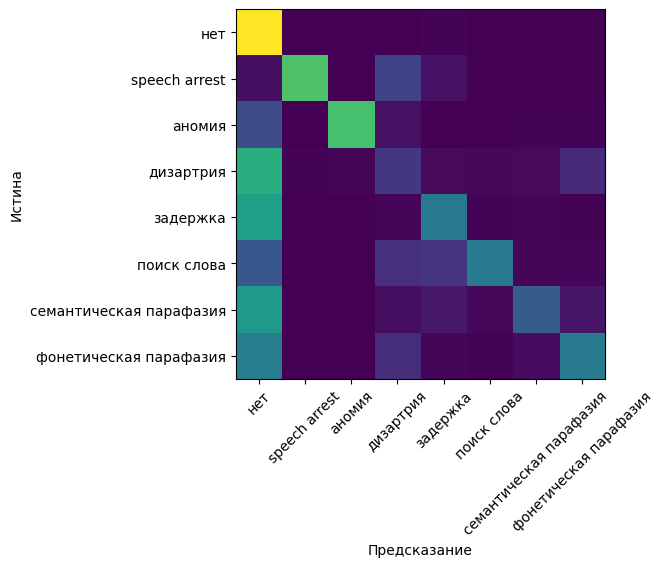

In [15]:
evaluate(DecisionTreeClassifier(max_depth=10),
         output_separate_f1s=True)


# Бейзлайн

In [6]:
best_macro_F1 = 0.0
best_max_depth = 0
for max_depth in range(1, 13):
    score = evaluate(DecisionTreeClassifier(max_depth=max_depth, 
                                            random_state=SEED),
                                            supress_plot=True,
                                            supress_print=True)
    if score > best_macro_F1:
        best_macro_F1 = score
        best_max_depth = max_depth


In [7]:
best_max_depth


11

5it [00:05,  1.01s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.82±0.16	0.84±0.15	0.82±0.13
аномия                  0.73±0.08	0.72±0.12	0.72±0.07
дизартрия               0.39±0.06	0.17±0.04	0.23±0.05
задержка                0.68±0.03	0.41±0.03	0.51±0.03
поиск слова             0.55±0.10	0.37±0.09	0.43±0.06
семантическая парафазия 0.50±0.14	0.30±0.07	0.37±0.09
фонетическая парафазия  0.61±0.07	0.41±0.05	0.49±0.04
По всем                 0.65±0.02	0.53±0.02	0.57±0.02


np.float64(0.5681625343770861)

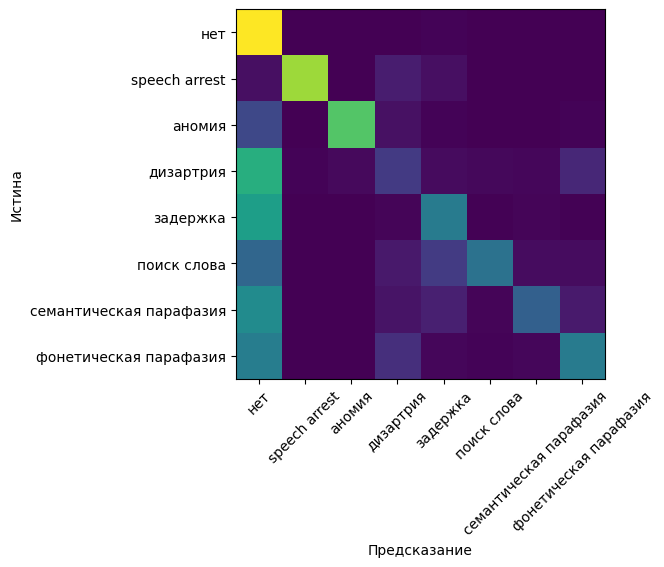

In [18]:
evaluate(DecisionTreeClassifier(max_depth=best_max_depth, 
                                random_state=SEED))


# Простые решения

5it [00:52, 10.50s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.96±0.00	0.95±0.00
speech arrest           0.79±0.11	0.76±0.15	0.77±0.12
аномия                  0.75±0.08	0.70±0.11	0.72±0.09
дизартрия               0.25±0.03	0.18±0.02	0.21±0.02
задержка                0.44±0.02	0.38±0.01	0.41±0.01
поиск слова             0.47±0.10	0.48±0.14	0.47±0.12
семантическая парафазия 0.65±0.08	0.37±0.09	0.47±0.09
фонетическая парафазия  0.53±0.07	0.45±0.07	0.49±0.06
По всем                 0.60±0.02	0.54±0.02	0.56±0.01


np.float64(0.5617729441194071)

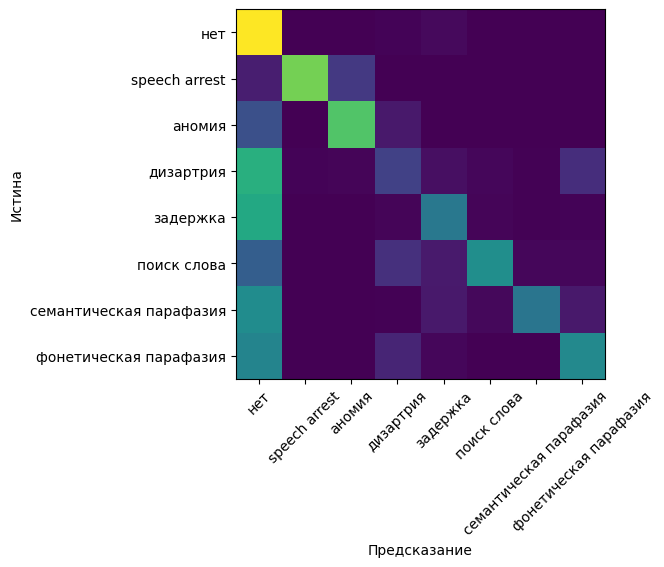

In [19]:
evaluate(RandomForestClassifier(random_state=SEED))


5it [02:55, 35.07s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.97±0.00
speech arrest           0.87±0.11	0.79±0.22	0.79±0.12
аномия                  0.74±0.08	0.70±0.12	0.72±0.10
дизартрия               0.58±0.10	0.17±0.03	0.27±0.05
задержка                0.71±0.02	0.43±0.01	0.54±0.02
поиск слова             0.65±0.13	0.56±0.13	0.59±0.10
семантическая парафазия 0.60±0.07	0.45±0.11	0.51±0.09
фонетическая парафазия  0.67±0.02	0.48±0.03	0.56±0.02
По всем                 0.72±0.02	0.57±0.02	0.62±0.03


np.float64(0.6170592953108391)

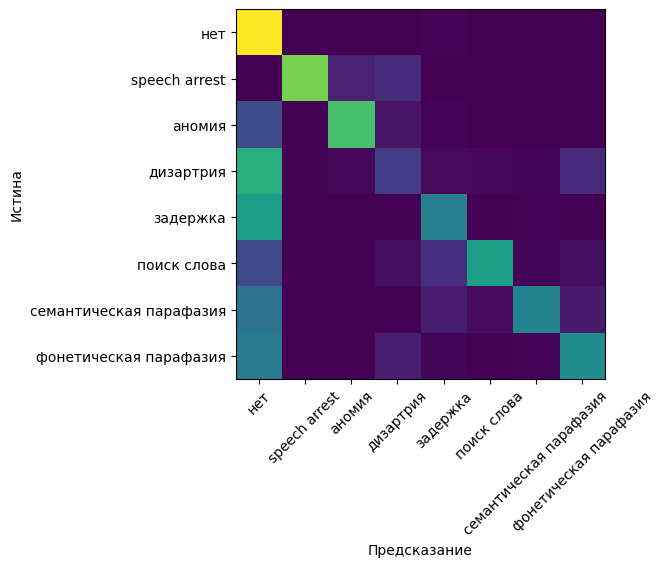

In [20]:
evaluate(catboost.CatBoostClassifier(task_type='GPU',
                                    devices='0',
                                    random_state=SEED,
                                    silent=True))


# Ансамблирование

Посмотрим, какие классы (группы классов) простое decision tree лучше всего может разделить. Также посмотрим, какие признаки оно для этого использует

In [21]:
column_group_names = ['RT_start', 'relative_length',
                      '^.+_normalized_total$', '^word_list_.+$',
                      '^ruwordnet_.+$', '^.+_[а-яё ]$']


In [22]:
def get_powerset(items):
    items = list(items)
    return chain.from_iterable(combinations(items, r)
                               for r in range(len(items) + 1))


In [23]:
combinations_some_v_rest = [list(i)
                for i in itertools.product([0, 1], repeat=8)][1:130]


In [24]:
macro_f1s_SvR: list[float] = []
trees_SvR: list[DecisionTreeClassifier] = []

for combination in combinations_some_v_rest:
    tree = DecisionTreeClassifier(max_depth=best_max_depth, 
                                random_state=SEED)
    macro_f1s_SvR.append(evaluate(tree,
                              merge_classes=combination,
                              supress_plot=True,
                              supress_print=True))
    trees_SvR.append(tree)


In [25]:
joblib.dump((macro_f1s_SvR, trees_SvR),
            'class_subsets_bruteforce.joblib.xz', 9)


['class_subsets_bruteforce.joblib.xz']

In [26]:
macro_f1s_SvR, trees_SvR =\
      joblib.load('class_subsets_bruteforce.joblib.xz')


In [27]:
np.set_printoptions(linewidth=72, threshold=float('+inf'))

In [28]:
np.array(macro_f1s_SvR)[np.argsort(-np.array(macro_f1s_SvR))]

array([0.86708182, 0.84692152, 0.84648544, 0.83050987, 0.81071502,
       0.80473971, 0.79347735, 0.79253277, 0.79188348, 0.79008121,
       0.78991534, 0.78779554, 0.78563587, 0.78399213, 0.78368101,
       0.78258548, 0.7795864 , 0.77866645, 0.77851034, 0.77848893,
       0.77806283, 0.77619744, 0.77506862, 0.77307361, 0.77196325,
       0.77135349, 0.77075803, 0.77021999, 0.76995724, 0.76910375,
       0.76872181, 0.76802382, 0.76713157, 0.7657755 , 0.76467602,
       0.76412418, 0.76404738, 0.76159577, 0.76139062, 0.76049111,
       0.76044705, 0.7597346 , 0.75864229, 0.75825118, 0.75651176,
       0.75644203, 0.75625181, 0.7561916 , 0.75580575, 0.75540061,
       0.75518239, 0.75483605, 0.75329766, 0.75324797, 0.75301145,
       0.75300634, 0.75284813, 0.7518834 , 0.75147017, 0.75105939,
       0.75019596, 0.75009228, 0.74995891, 0.74938632, 0.74898867,
       0.74863274, 0.74779069, 0.74763612, 0.74741493, 0.74632544,
       0.74600432, 0.74561795, 0.74541768, 0.74531208, 0.74490

In [29]:
np.array(combinations_some_v_rest)[np.argsort(-np.array(macro_f1s_SvR))]


array([[0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 0],
       [0, 1, 1, 0, 0, 0, 1, 0],
       [0, 1, 1, 1, 0, 1, 0, 1],
       [0, 0, 1, 0, 0, 0, 1, 0],
       [0, 1, 1, 1, 0, 0, 0, 1],
       [0, 1, 1, 0, 0, 1, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1],
       [0, 1, 0, 1, 0, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1, 1],
       [0, 0, 1, 1, 0, 1, 0, 1],
       [0, 1, 0, 0, 0, 1, 0, 0],
       [0, 1, 1, 1, 1, 1, 0, 1],
       [0, 0, 1, 0, 0, 1, 1, 0],
       [0, 1, 1, 1, 0, 1, 1, 1],
       [0, 0, 1, 1, 0, 0, 0, 1],
       [0, 1, 0, 1, 1, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 0, 1],
       [0, 0, 0, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 0, 1, 1],
       [0, 0, 1, 1, 0, 1, 1, 1],
       [0, 1, 1, 0, 1, 1, 1, 1],
       [0, 0, 1, 0, 1, 1, 1, 1],
       [0, 1, 1, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 1, 1, 1],
       [0,

## 1 vs all

In [30]:
np.array(combinations_some_v_rest)[np.array(combinations_some_v_rest)\
                                .sum(axis=1) == 1][::-1]

array([[1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1]])

In [31]:
np.argsort(-np.array(macro_f1s_SvR)[np.array(combinations_some_v_rest)\
                                .sum(axis=1) == 1][::-1])


array([2, 1, 0, 6, 4, 5, 7, 3])

In [32]:
np.sort(np.array(macro_f1s_SvR)[np.array(combinations_some_v_rest)\
                                .sum(axis=1) == 1][::-1])[::-1]

array([0.84692152, 0.84648544, 0.78991534, 0.75329766, 0.73062984,
       0.70170983, 0.69609546, 0.5668464 ])

## one vs one

In [33]:
combinations_one_v_one = [set(i)
                for i in itertools.combinations([0,1,2,3,4,5,6,7], 2)]

In [34]:
macro_f1s_1v1: list[float] = []

for combination in combinations_one_v_one:
    this_max_depth = int(np.floor(np.log2(folds_train[0][1]\
                                .is_in(combination)\
                                .cast(pl.Int8)\
                                .sum())) - 1)

    tree = DecisionTreeClassifier(max_depth=this_max_depth,
                                random_state=SEED)
    macro_f1s_1v1.append(evaluate(tree,
                              include_classes=combination,
                              supress_plot=True,
                              supress_print=True))


In [35]:
np.array(macro_f1s_1v1)[np.argsort(-np.array(macro_f1s_1v1))]

array([1.        , 1.        , 1.        , 1.        , 0.99061924,
       0.94980672, 0.9376798 , 0.9304713 , 0.92465337, 0.90538749,
       0.88370272, 0.88144795, 0.87285217, 0.86991898, 0.85914936,
       0.85519647, 0.84721689, 0.84308507, 0.8422392 , 0.83948052,
       0.8296468 , 0.82456308, 0.79505905, 0.78807478, 0.7631614 ,
       0.73776441, 0.58042898, 0.58035907])

In [36]:
np.array(combinations_one_v_one)[np.argsort(-np.array(macro_f1s_1v1))]


array([{1, 2}, {1, 7}, {1, 5}, {1, 6}, {1, 4}, {2, 4}, {2, 5}, {0, 1},
       {2, 7}, {2, 6}, {0, 2}, {2, 3}, {3, 6}, {1, 3}, {6, 7}, {5, 6},
       {3, 5}, {5, 7}, {4, 7}, {4, 6}, {0, 5}, {4, 5}, {0, 7}, {3, 4},
       {0, 6}, {0, 4}, {0, 3}, {3, 7}], dtype=object)

In [37]:
pl.DataFrame([list(x) for x in combinations_one_v_one],
             schema=['class_1', 'class_2'])\
             .with_columns(pl.Series(macro_f1s_1v1).alias('f1'))\
             .pivot(index='class_1', on='class_2')

C:\Users\Vlad\AppData\Local\Temp\ipykernel_15460\3412461344.py:1: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  pl.DataFrame([list(x) for x in combinations_one_v_one],


class_1,1,2,3,4,5,6,7
i64,f64,f64,f64,f64,f64,f64,f64
0,0.930471,0.883703,0.580429,0.737764,0.829647,0.763161,0.795059
1,null,1.0,0.869919,0.990619,1.0,1.0,1.0
2,null,null,0.881448,0.949807,0.93768,0.905387,0.924653
3,null,null,null,0.788075,0.847217,0.872852,0.580359
4,null,null,null,null,0.824563,0.839481,0.842239
5,null,null,null,null,null,0.855196,0.843085
6,null,null,null,null,null,null,0.859149


У обоих способов получаются результаты лучше, чем у просто дерева. С 1v1 есть проблема с неизвестными базовой модели классами, поэтому попробуем 1vR.

In [38]:
base_model = DecisionTreeClassifier(max_depth=best_max_depth, 
                                random_state=SEED)
ovr_classifier = OneVsRestClassifier(base_model)


5it [00:34,  6.89s/it]

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.98±0.00	0.96±0.00
speech arrest           0.84±0.14	0.68±0.32	0.69±0.24
аномия                  0.73±0.11	0.69±0.11	0.71±0.11
дизартрия               0.25±0.08	0.17±0.08	0.20±0.09
задержка                0.58±0.03	0.39±0.02	0.47±0.02
поиск слова             0.48±0.18	0.32±0.11	0.38±0.12
семантическая парафазия 0.56±0.13	0.40±0.13	0.46±0.12
фонетическая парафазия  0.56±0.08	0.32±0.04	0.41±0.02
По всем                 0.62±0.01	0.49±0.02	0.53±0.03


np.float64(0.5340601387004791)

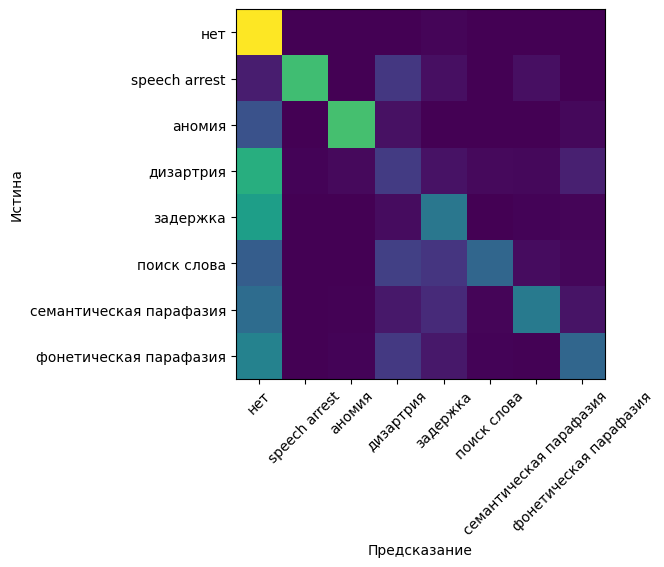

In [39]:
evaluate(ovr_classifier)


## 1 vs 1 с нейтральным классом

In [40]:
combinations_1v1vN_ = set(itertools.permutations([1,1,0,0,0,0,0,0]))

In [41]:
combinations_1v1vN = set()
for combination in combinations_1v1vN_:
    combination = list(combination)
    combination[combination.index(1)] = -1
    combinations_1v1vN.add(tuple(combination))


In [42]:
macro_f1s_1v1vN: list[float] = []

for combination in tqdm(combinations_1v1vN):
    tree = DecisionTreeClassifier(max_depth=best_max_depth, 
                                random_state=SEED)
    macro_f1s_1v1vN.append(evaluate(tree,
                              merge_classes=combination,
                              supress_plot=True,
                              supress_print=True))


100%|██████████| 28/28 [02:03<00:00,  4.41s/it]


In [43]:
sorted(macro_f1s_1v1vN)

[np.float64(0.5261128540133517),
 np.float64(0.526382560319639),
 np.float64(0.5426751560445591),
 np.float64(0.5466152162899574),
 np.float64(0.5792557711712879),
 np.float64(0.5984966460211403),
 np.float64(0.6099425162194193),
 np.float64(0.6136040877768525),
 np.float64(0.6222104398661154),
 np.float64(0.6228147109112581),
 np.float64(0.6229488261082741),
 np.float64(0.6291225590981917),
 np.float64(0.6440321554948949),
 np.float64(0.6460095076220813),
 np.float64(0.6489435231979048),
 np.float64(0.6592185312058094),
 np.float64(0.6897448858441878),
 np.float64(0.6899813632872028),
 np.float64(0.7045824851326705),
 np.float64(0.7063407759207398),
 np.float64(0.7091414854163008),
 np.float64(0.7152993598011956),
 np.float64(0.7306481121997597),
 np.float64(0.7403157223328038),
 np.float64(0.7535580302651447),
 np.float64(0.7585811114709535),
 np.float64(0.784002126420582),
 np.float64(0.8001447674394916)]

## Подбор признаков для каждого 1v1vN

In [44]:
column_groups_to_use: list[tuple[str,...]] = list(
                                    get_powerset(column_group_names))

In [45]:
f1s_for_column_groups_1v1vn = np.zeros((28, 64, 3))
for i, combination in tqdm(enumerate(combinations_1v1vN)):
    # print(i, combination)
    for j, column_groups in enumerate(column_groups_to_use):
        # print(j, column_groups)
        f1s_for_column_groups_1v1vn[i, j] = evaluate(
                    DecisionTreeClassifier(max_depth=best_max_depth,
                                        random_state=SEED),
                    output_separate_f1s=True,
                    include_features=list(column_groups),
                    merge_classes=list(combination),
                    supress_print=True,
                    supress_plot=True)
        print(*f1s_for_column_groups_1v1vn[i, j].round(2))
    print(*f1s_for_column_groups_1v1vn.max(axis=(0,1)), '====')


0it [00:00, ?it/s]

0.75 0.99 0.12
0.0 0.99 0.0
0.0 0.99 0.09
0.0 0.99 0.13
0.0 0.99 0.17
0.23 0.99 0.14
0.53 0.99 0.05
0.0 0.99 0.11
0.0 0.99 0.12
0.0 0.99 0.17
0.23 0.99 0.16
0.52 0.99 0.05
0.0 0.99 0.11
0.0 0.99 0.2
0.53 0.99 0.17
0.78 0.99 0.06
0.0 0.99 0.18
0.58 0.99 0.16
0.7 0.99 0.05
0.21 0.99 0.15
0.57 0.99 0.09
0.58 0.99 0.13
0.0 0.99 0.1
0.0 0.99 0.16
0.58 0.99 0.17
0.73 0.99 0.06
0.0 0.99 0.17
0.56 0.99 0.15
0.77 0.99 0.05
0.26 0.99 0.18
0.57 0.99 0.1
0.61 0.99 0.11
0.0 0.99 0.18
0.59 0.99 0.18
0.71 0.99 0.05
0.58 0.99 0.2
0.82 0.99 0.1
0.71 0.99 0.12
0.56 0.99 0.21
0.76 0.99 0.09
0.83 0.99 0.12
0.46 0.99 0.1
0.0 0.99 0.16
0.54 0.99 0.18
0.7 0.99 0.06
0.6 0.99 0.22
0.76 0.99 0.11
0.77 0.99 0.12
0.56 0.99 0.2
0.76 0.99 0.1
0.8 0.99 0.15
0.51 0.99 0.1
0.54 0.99 0.19
0.82 0.99 0.1
0.72 0.99 0.12
0.78 0.99 0.1
0.71 0.99 0.11
0.58 0.99 0.2
0.79 0.99 0.11
0.86 0.99 0.14
0.73 0.99 0.11
0.81 0.99 0.11
0.8 0.99 0.12


1it [03:06, 186.49s/it]

0.75 0.99 0.12
0.8595959595959595 0.9906576255841225 0.21816583687596794 ====
0.71 0.99 0.09
0.27 0.99 0.0
0.56 0.99 0.09
0.69 0.99 0.14
0.67 0.99 0.17
0.42 0.99 0.15
0.52 0.99 0.05
0.72 0.99 0.11
0.71 0.99 0.13
0.66 0.99 0.15
0.57 0.99 0.16
0.52 0.99 0.05
0.7 0.99 0.13
0.74 0.99 0.17
0.63 0.99 0.17
0.68 0.99 0.08
0.74 0.99 0.15
0.63 0.99 0.16
0.69 0.99 0.09
0.53 0.99 0.15
0.63 0.99 0.1
0.54 0.99 0.09
0.73 0.99 0.15
0.73 0.99 0.14
0.65 0.99 0.19
0.65 0.99 0.05
0.73 0.99 0.16
0.67 0.99 0.18
0.65 0.99 0.07
0.53 0.99 0.15
0.65 0.99 0.12
0.5 0.99 0.07
0.73 0.99 0.15
0.66 0.99 0.2
0.66 0.99 0.07
0.68 0.99 0.18
0.7 0.99 0.1
0.7 0.99 0.08
0.7 0.99 0.21
0.69 0.99 0.1
0.65 0.99 0.11
0.58 0.99 0.11
0.72 0.99 0.16
0.68 0.99 0.19
0.67 0.99 0.05
0.68 0.99 0.17
0.68 0.99 0.11
0.68 0.99 0.09
0.71 0.99 0.16
0.68 0.99 0.1
0.66 0.99 0.09
0.58 0.99 0.1
0.69 0.99 0.2
0.7 0.99 0.1
0.65 0.99 0.08
0.69 0.99 0.09
0.7 0.99 0.12
0.69 0.99 0.16
0.69 0.99 0.11
0.66 0.99 0.08
0.67 0.99 0.09
0.71 0.99 0.1
0.7 0.99 

2it [06:21, 191.69s/it]

0.71 0.99 0.09
0.8595959595959595 0.9906576255841225 0.21816583687596794 ====
0.49 0.98 0.4
0.23 0.97 0.0
0.02 0.97 0.19
0.11 0.97 0.34
0.07 0.97 0.22
0.03 0.97 0.35
0.22 0.97 0.37
0.43 0.97 0.16
0.47 0.97 0.27
0.43 0.97 0.15
0.41 0.97 0.18
0.51 0.98 0.47
0.11 0.97 0.32
0.11 0.97 0.24
0.11 0.97 0.22
0.21 0.97 0.43
0.15 0.97 0.34
0.09 0.97 0.21
0.22 0.97 0.48
0.1 0.97 0.17
0.2 0.97 0.42
0.21 0.97 0.52
0.46 0.97 0.31
0.45 0.97 0.27
0.44 0.97 0.23
0.51 0.98 0.5
0.45 0.97 0.17
0.43 0.97 0.21
0.51 0.98 0.49
0.42 0.97 0.27
0.49 0.98 0.44
0.5 0.98 0.43
0.14 0.97 0.3
0.13 0.97 0.25
0.21 0.97 0.45
0.11 0.97 0.21
0.2 0.97 0.37
0.21 0.97 0.52
0.1 0.97 0.24
0.21 0.97 0.36
0.22 0.97 0.47
0.21 0.97 0.41
0.46 0.97 0.2
0.43 0.97 0.19
0.51 0.98 0.49
0.45 0.97 0.22
0.49 0.98 0.48
0.49 0.98 0.43
0.43 0.97 0.23
0.48 0.98 0.42
0.5 0.98 0.41
0.49 0.98 0.4
0.12 0.97 0.22
0.21 0.97 0.41
0.21 0.97 0.48
0.21 0.97 0.47
0.21 0.97 0.43
0.43 0.97 0.27
0.49 0.98 0.39
0.49 0.98 0.44
0.49 0.98 0.4
0.49 0.98 0.36
0.21 

3it [09:04, 178.63s/it]

0.49 0.98 0.4
0.8595959595959595 0.9906576255841225 0.5175479491268965 ====
0.96 0.57 0.2
0.95 0.23 0.0
0.95 0.25 0.09
0.96 0.39 0.16
0.95 0.28 0.14
0.96 0.33 0.14
0.95 0.36 0.05
0.95 0.44 0.12
0.96 0.53 0.11
0.96 0.46 0.14
0.96 0.51 0.15
0.96 0.51 0.03
0.96 0.4 0.16
0.95 0.33 0.12
0.96 0.41 0.17
0.96 0.36 0.1
0.96 0.41 0.16
0.96 0.41 0.15
0.96 0.42 0.09
0.96 0.4 0.18
0.96 0.34 0.11
0.96 0.43 0.15
0.96 0.53 0.1
0.95 0.47 0.11
0.96 0.55 0.13
0.96 0.51 0.06
0.96 0.53 0.15
0.96 0.54 0.16
0.96 0.57 0.08
0.96 0.53 0.16
0.96 0.49 0.09
0.96 0.58 0.18
0.96 0.37 0.17
0.96 0.43 0.14
0.96 0.43 0.12
0.96 0.42 0.19
0.95 0.35 0.12
0.96 0.43 0.18
0.96 0.43 0.13
0.96 0.43 0.15
0.96 0.44 0.17
0.96 0.44 0.21
0.96 0.54 0.14
0.96 0.55 0.15
0.96 0.57 0.1
0.96 0.54 0.17
0.96 0.5 0.1
0.96 0.58 0.21
0.96 0.55 0.18
0.96 0.56 0.13
0.96 0.57 0.23
0.96 0.56 0.18
0.96 0.44 0.15
0.96 0.44 0.16
0.96 0.45 0.19
0.96 0.44 0.18
0.96 0.44 0.18
0.96 0.55 0.19
0.96 0.56 0.12
0.96 0.58 0.22
0.96 0.57 0.2
0.96 0.57 0.19
0.96

4it [11:02, 154.53s/it]

0.96 0.57 0.2
0.9635913335557331 0.9906576255841225 0.5175479491268965 ====
0.96 0.61 0.78
0.95 0.2 0.0
0.95 0.28 0.0
0.96 0.42 0.0
0.95 0.3 0.0
0.96 0.4 0.15
0.96 0.36 0.64
0.95 0.41 0.0
0.96 0.53 0.0
0.95 0.46 0.0
0.96 0.54 0.21
0.96 0.48 0.61
0.96 0.42 0.0
0.95 0.36 0.0
0.96 0.47 0.6
0.95 0.33 0.73
0.96 0.44 0.0
0.96 0.49 0.47
0.96 0.44 0.76
0.96 0.45 0.19
0.95 0.34 0.74
0.96 0.5 0.45
0.96 0.53 0.0
0.95 0.45 0.0
0.96 0.58 0.55
0.96 0.48 0.76
0.96 0.54 0.0
0.96 0.57 0.47
0.96 0.57 0.87
0.96 0.57 0.19
0.96 0.47 0.76
0.96 0.6 0.3
0.96 0.43 0.0
0.96 0.48 0.46
0.96 0.44 0.76
0.96 0.48 0.6
0.95 0.34 0.71
0.96 0.5 0.73
0.96 0.48 0.51
0.96 0.45 0.73
0.96 0.5 0.71
0.96 0.51 0.54
0.96 0.54 0.0
0.96 0.58 0.48
0.96 0.57 0.8
0.96 0.58 0.5
0.96 0.48 0.76
0.96 0.6 0.7
0.96 0.57 0.55
0.96 0.56 0.8
0.96 0.6 0.76
0.96 0.6 0.46
0.96 0.49 0.42
0.96 0.46 0.73
0.96 0.5 0.68
0.96 0.51 0.71
0.96 0.5 0.69
0.96 0.58 0.57
0.96 0.56 0.8
0.96 0.6 0.83
0.96 0.6 0.71
0.96 0.6 0.74
0.96 0.51 0.73


5it [13:01, 141.79s/it]

0.96 0.61 0.78
0.9635913335557331 0.9906576255841225 0.865050505050505 ====
0.68 1.0 0.43
0.0 1.0 0.0
0.55 1.0 0.19
0.68 1.0 0.31
0.66 0.99 0.16
0.37 0.99 0.27
0.54 1.0 0.27
0.71 1.0 0.25
0.74 1.0 0.36
0.66 0.99 0.14
0.52 0.99 0.2
0.57 1.0 0.46
0.69 1.0 0.32
0.71 1.0 0.23
0.63 1.0 0.31
0.69 1.0 0.46
0.72 1.0 0.21
0.64 1.0 0.27
0.66 1.0 0.44
0.54 0.99 0.2
0.65 1.0 0.42
0.53 1.0 0.42
0.74 1.0 0.38
0.72 1.0 0.19
0.64 1.0 0.31
0.65 1.0 0.55
0.72 1.0 0.2
0.66 1.0 0.26
0.64 1.0 0.52
0.52 0.99 0.24
0.67 1.0 0.52
0.52 1.0 0.44
0.71 1.0 0.24
0.62 1.0 0.28
0.69 1.0 0.41
0.67 1.0 0.2
0.73 1.0 0.36
0.68 1.0 0.44
0.67 1.0 0.19
0.71 1.0 0.38
0.63 1.0 0.49
0.58 1.0 0.35
0.71 1.0 0.19
0.64 1.0 0.26
0.67 1.0 0.54
0.67 1.0 0.22
0.7 1.0 0.51
0.66 1.0 0.44
0.65 1.0 0.25
0.69 1.0 0.56
0.63 1.0 0.48
0.6 1.0 0.4
0.67 1.0 0.22
0.7 1.0 0.36
0.69 1.0 0.45
0.73 1.0 0.44
0.7 1.0 0.33
0.65 1.0 0.23
0.69 1.0 0.52
0.66 1.0 0.45
0.69 1.0 0.47
0.69 1.0 0.47
0.7 1.0 0.4


6it [16:30, 164.69s/it]

0.68 1.0 0.43
0.9635913335557331 0.9968654107157036 0.865050505050505 ====
0.69 1.0 0.71
0.0 1.0 0.27
0.0 1.0 0.55
0.0 1.0 0.69
0.0 1.0 0.66
0.2 1.0 0.41
0.55 1.0 0.55
0.0 1.0 0.72
0.0 1.0 0.7
0.0 1.0 0.64
0.19 1.0 0.52
0.64 1.0 0.54
0.0 1.0 0.69
0.0 1.0 0.73
0.55 1.0 0.65
0.76 1.0 0.7
0.0 1.0 0.74
0.5 1.0 0.65
0.73 1.0 0.63
0.17 1.0 0.54
0.69 1.0 0.63
0.55 1.0 0.54
0.0 1.0 0.69
0.0 1.0 0.71
0.51 1.0 0.62
0.85 1.0 0.65
0.0 1.0 0.73
0.53 1.0 0.64
0.79 1.0 0.65
0.17 1.0 0.54
0.71 1.0 0.64
0.4 1.0 0.51
0.0 1.0 0.73
0.63 1.0 0.66
0.76 1.0 0.71
0.5 1.0 0.7
0.73 1.0 0.72
0.84 1.0 0.69
0.55 1.0 0.7
0.76 1.0 0.71
0.68 1.0 0.66
0.52 1.0 0.6
0.0 1.0 0.72
0.51 1.0 0.63
0.85 1.0 0.65
0.55 1.0 0.66
0.76 1.0 0.69
0.8 1.0 0.67
0.53 1.0 0.69
0.79 1.0 0.71
0.83 1.0 0.66
0.65 1.0 0.61
0.51 1.0 0.71
0.71 1.0 0.73
0.84 1.0 0.69
0.68 1.0 0.72
0.82 1.0 0.72
0.49 1.0 0.67
0.76 1.0 0.68
0.8 1.0 0.7
0.7 1.0 0.7
0.67 1.0 0.7
0.84 1.0 0.72


7it [19:32, 170.27s/it]

0.69 1.0 0.71
0.9635913335557331 0.9982681183221087 0.865050505050505 ====
0.49 0.97 0.47
0.23 0.97 0.0
0.04 0.97 0.18
0.11 0.97 0.32
0.06 0.97 0.02
0.02 0.97 0.39
0.22 0.97 0.4
0.42 0.97 0.13
0.47 0.97 0.23
0.4 0.97 0.01
0.42 0.97 0.37
0.52 0.98 0.22
0.11 0.97 0.33
0.08 0.97 0.3
0.12 0.97 0.45
0.21 0.97 0.39
0.12 0.97 0.4
0.09 0.97 0.38
0.19 0.97 0.38
0.08 0.97 0.49
0.19 0.97 0.39
0.18 0.97 0.39
0.47 0.97 0.2
0.44 0.97 0.16
0.45 0.97 0.35
0.51 0.98 0.24
0.44 0.97 0.31
0.48 0.97 0.35
0.51 0.97 0.32
0.43 0.97 0.39
0.48 0.97 0.23
0.5 0.98 0.38
0.12 0.97 0.41
0.14 0.97 0.43
0.18 0.97 0.36
0.1 0.97 0.46
0.19 0.97 0.37
0.19 0.97 0.39
0.1 0.97 0.49
0.18 0.97 0.42
0.19 0.97 0.38
0.2 0.97 0.48
0.45 0.97 0.27
0.46 0.97 0.34
0.51 0.97 0.3
0.46 0.97 0.39
0.48 0.97 0.26
0.49 0.97 0.38
0.44 0.97 0.37
0.48 0.97 0.32
0.49 0.97 0.38
0.5 0.97 0.43
0.12 0.97 0.5
0.18 0.97 0.45
0.19 0.97 0.37
0.2 0.97 0.48
0.18 0.97 0.48
0.45 0.97 0.38
0.49 0.97 0.35
0.5 0.97 0.35
0.49 0.97 0.46
0.49 0.97 0.43
0.19 0.97 

8it [21:45, 158.50s/it]

0.49 0.97 0.47
0.9635913335557331 0.9982681183221087 0.865050505050505 ====
0.1 0.99 0.49
0.03 0.99 0.0
0.1 0.99 0.15
0.18 0.99 0.33
0.17 0.99 0.02
0.14 0.99 0.42
0.04 0.99 0.41
0.12 0.98 0.07
0.15 0.98 0.26
0.16 0.98 0.02
0.14 0.98 0.38
0.03 0.99 0.4
0.18 0.99 0.32
0.13 0.99 0.17
0.22 0.99 0.48
0.04 0.99 0.37
0.2 0.99 0.49
0.15 0.99 0.47
0.06 0.99 0.37
0.19 0.99 0.51
0.06 0.99 0.37
0.07 0.99 0.47
0.16 0.98 0.27
0.13 0.99 0.24
0.17 0.99 0.42
0.05 0.99 0.39
0.19 0.99 0.44
0.14 0.99 0.41
0.08 0.99 0.35
0.19 0.99 0.48
0.08 0.99 0.39
0.06 0.99 0.48
0.19 0.99 0.5
0.15 0.99 0.48
0.07 0.99 0.37
0.17 0.99 0.47
0.06 0.99 0.4
0.08 0.99 0.45
0.2 0.99 0.49
0.1 0.99 0.37
0.09 0.99 0.43
0.09 0.99 0.5
0.18 0.99 0.47
0.15 0.99 0.46
0.06 0.99 0.35
0.2 0.99 0.45
0.08 0.99 0.39
0.07 0.99 0.44
0.2 0.99 0.47
0.12 0.99 0.32
0.08 0.99 0.44
0.09 0.99 0.47
0.18 0.99 0.48
0.1 0.99 0.34
0.09 0.99 0.43
0.1 0.99 0.48
0.12 0.99 0.48
0.2 0.99 0.47
0.13 0.99 0.32
0.09 0.99 0.45
0.1 0.99 0.49
0.12 0.99 0.47
0.11 0.99 

9it [24:22, 157.93s/it]

0.1 0.99 0.49
0.9635913335557331 0.9982681183221087 0.865050505050505 ====
0.68 1.0 0.44
0.0 0.99 0.0
0.0 1.0 0.15
0.0 0.99 0.32
0.0 0.99 0.01
0.19 0.99 0.38
0.59 1.0 0.38
0.0 0.99 0.12
0.0 0.99 0.31
0.0 0.99 0.05
0.21 0.99 0.43
0.52 1.0 0.38
0.0 0.99 0.36
0.0 1.0 0.33
0.55 1.0 0.47
0.62 1.0 0.38
0.0 1.0 0.47
0.65 1.0 0.45
0.61 1.0 0.39
0.2 0.99 0.48
0.45 1.0 0.38
0.4 1.0 0.45
0.0 0.99 0.32
0.0 0.99 0.22
0.52 1.0 0.49
0.69 1.0 0.38
0.0 0.99 0.45
0.57 0.99 0.44
0.66 1.0 0.41
0.19 0.99 0.46
0.49 1.0 0.39
0.4 1.0 0.46
0.0 0.99 0.47
0.6 1.0 0.44
0.61 1.0 0.4
0.58 0.99 0.42
0.62 1.0 0.39
0.54 1.0 0.44
0.62 1.0 0.44
0.61 1.0 0.44
0.65 1.0 0.43
0.33 1.0 0.49
0.0 0.99 0.47
0.63 1.0 0.46
0.67 1.0 0.42
0.59 0.99 0.45
0.67 1.0 0.38
0.54 1.0 0.44
0.6 0.99 0.43
0.66 1.0 0.41
0.53 1.0 0.46
0.29 1.0 0.5
0.56 1.0 0.45
0.6 1.0 0.42
0.52 1.0 0.44
0.61 1.0 0.45
0.65 1.0 0.42
0.61 1.0 0.46
0.73 1.0 0.41
0.56 1.0 0.44
0.71 1.0 0.47
0.51 1.0 0.46
0.62 1.0 0.44


10it [26:56, 156.74s/it]

0.68 1.0 0.44
0.9635913335557331 0.9982681183221087 0.865050505050505 ====
0.82 1.0 0.45
0.0 1.0 0.0
0.0 1.0 0.19
0.0 1.0 0.33
0.0 1.0 0.16
0.16 1.0 0.23
0.47 1.0 0.28
0.0 1.0 0.25
0.0 1.0 0.4
0.0 1.0 0.11
0.17 1.0 0.17
0.47 1.0 0.47
0.0 1.0 0.33
0.0 1.0 0.19
0.52 1.0 0.27
0.73 1.0 0.38
0.0 1.0 0.22
0.59 1.0 0.3
0.73 1.0 0.43
0.18 1.0 0.22
0.43 1.0 0.41
0.48 1.0 0.5
0.0 1.0 0.38
0.0 1.0 0.2
0.55 1.0 0.28
0.76 1.0 0.51
0.0 1.0 0.14
0.54 1.0 0.23
0.76 1.0 0.49
0.21 1.0 0.19
0.4 1.0 0.48
0.57 1.0 0.43
0.0 1.0 0.21
0.62 1.0 0.32
0.76 1.0 0.38
0.6 1.0 0.26
0.73 1.0 0.38
0.69 1.0 0.42
0.53 1.0 0.24
0.73 1.0 0.36
0.68 1.0 0.47
0.56 1.0 0.45
0.0 1.0 0.23
0.56 1.0 0.22
0.79 1.0 0.51
0.45 1.0 0.24
0.79 1.0 0.51
0.72 1.0 0.42
0.55 1.0 0.26
0.76 1.0 0.47
0.85 1.0 0.48
0.56 1.0 0.41
0.6 1.0 0.3
0.76 1.0 0.37
0.66 1.0 0.43
0.67 1.0 0.43
0.84 1.0 0.39
0.57 1.0 0.33
0.76 1.0 0.52
0.69 1.0 0.46
0.83 1.0 0.45
0.85 1.0 0.44
0.84 1.0 0.44


11it [30:06, 166.93s/it]

0.82 1.0 0.45
0.9635913335557331 0.9982681183221087 0.865050505050505 ====
0.12 0.99 0.47
0.01 0.99 0.0
0.11 0.99 0.17
0.17 0.99 0.34
0.17 0.99 0.21
0.17 0.99 0.34
0.08 0.99 0.18
0.12 0.99 0.26
0.1 0.99 0.37
0.16 0.99 0.08
0.16 0.99 0.29
0.06 0.99 0.47
0.18 0.99 0.34
0.19 0.99 0.28
0.18 0.99 0.34
0.07 0.99 0.44
0.19 0.99 0.22
0.18 0.99 0.41
0.06 0.99 0.44
0.18 0.99 0.29
0.09 0.99 0.36
0.18 0.99 0.55
0.1 0.99 0.35
0.14 0.99 0.21
0.17 0.99 0.41
0.05 0.99 0.5
0.16 0.99 0.2
0.16 0.99 0.32
0.05 0.99 0.52
0.16 0.99 0.21
0.11 0.99 0.44
0.18 0.99 0.48
0.18 0.99 0.2
0.21 0.99 0.41
0.06 0.99 0.47
0.21 0.99 0.3
0.1 0.99 0.3
0.19 0.99 0.53
0.18 0.99 0.32
0.1 0.99 0.3
0.18 0.99 0.54
0.13 0.99 0.52
0.16 0.99 0.2
0.17 0.99 0.31
0.05 0.99 0.5
0.21 0.99 0.23
0.11 0.99 0.43
0.16 0.99 0.47
0.24 0.99 0.3
0.11 0.99 0.45
0.2 0.99 0.47
0.12 0.99 0.48
0.19 0.99 0.31
0.09 0.99 0.31
0.19 0.99 0.51
0.12 0.99 0.48
0.11 0.99 0.46
0.23 0.99 0.33
0.11 0.99 0.46
0.17 0.99 0.42
0.12 0.99 0.46
0.12 0.99 0.46
0.11 0.99 

12it [33:19, 174.68s/it]

0.12 0.99 0.47
0.9635913335557331 0.9982681183221087 0.865050505050505 ====
0.96 0.55 0.47
0.95 0.29 0.0
0.95 0.28 0.0
0.96 0.35 0.45
0.95 0.26 0.18
0.96 0.33 0.31
0.95 0.34 0.19
0.95 0.45 0.01
0.96 0.5 0.41
0.95 0.44 0.18
0.96 0.49 0.41
0.96 0.51 0.09
0.96 0.36 0.47
0.96 0.35 0.15
0.96 0.36 0.42
0.95 0.36 0.16
0.96 0.38 0.38
0.96 0.39 0.43
0.96 0.38 0.51
0.96 0.37 0.36
0.95 0.35 0.16
0.96 0.4 0.53
0.96 0.49 0.39
0.95 0.46 0.18
0.96 0.5 0.44
0.96 0.51 0.12
0.96 0.5 0.35
0.96 0.52 0.44
0.96 0.53 0.48
0.96 0.51 0.41
0.96 0.51 0.1
0.96 0.54 0.5
0.96 0.37 0.4
0.96 0.38 0.44
0.96 0.39 0.51
0.96 0.37 0.46
0.96 0.36 0.17
0.96 0.39 0.52
0.96 0.39 0.47
0.96 0.39 0.48
0.96 0.41 0.5
0.96 0.42 0.5
0.96 0.51 0.39
0.96 0.53 0.45
0.96 0.53 0.48
0.96 0.51 0.46
0.96 0.52 0.1
0.96 0.55 0.51
0.96 0.51 0.44
0.96 0.53 0.44
0.96 0.54 0.53
0.96 0.55 0.49
0.96 0.39 0.46
0.96 0.4 0.49
0.96 0.41 0.48
0.96 0.42 0.5
0.96 0.41 0.51
0.96 0.53 0.44
0.96 0.52 0.43
0.96 0.54 0.53
0.96 0.55 0.48
0.96 0.54 0.47
0.96 0.4

13it [35:19, 158.37s/it]

0.96 0.55 0.47
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.96 0.58 0.41
0.95 0.26 0.0
0.95 0.27 0.15
0.96 0.4 0.37
0.95 0.32 0.06
0.96 0.35 0.33
0.95 0.34 0.28
0.95 0.42 0.08
0.96 0.5 0.25
0.95 0.47 0.05
0.96 0.52 0.36
0.96 0.47 0.25
0.96 0.39 0.35
0.95 0.34 0.23
0.96 0.42 0.4
0.96 0.34 0.29
0.96 0.41 0.38
0.96 0.44 0.4
0.96 0.4 0.34
0.96 0.4 0.37
0.95 0.34 0.23
0.96 0.45 0.41
0.96 0.5 0.23
0.95 0.47 0.08
0.96 0.55 0.39
0.96 0.48 0.27
0.96 0.53 0.31
0.96 0.55 0.38
0.96 0.55 0.32
0.96 0.54 0.35
0.96 0.48 0.16
0.96 0.57 0.35
0.96 0.4 0.4
0.96 0.44 0.41
0.96 0.4 0.34
0.96 0.43 0.47
0.95 0.33 0.26
0.96 0.46 0.42
0.96 0.45 0.42
0.96 0.41 0.42
0.96 0.47 0.38
0.96 0.47 0.41
0.96 0.51 0.32
0.96 0.54 0.41
0.96 0.55 0.26
0.96 0.55 0.35
0.96 0.48 0.27
0.96 0.58 0.33
0.96 0.54 0.37
0.96 0.54 0.3
0.96 0.58 0.34
0.96 0.58 0.4
0.96 0.45 0.44
0.96 0.4 0.4
0.96 0.47 0.41
0.96 0.47 0.45
0.96 0.47 0.45
0.96 0.55 0.35
0.96 0.54 0.3
0.96 0.57 0.34
0.96 0.58 0.38
0.96 0.58 0.41
0.96 0.47 

14it [37:31, 150.27s/it]

0.96 0.58 0.41
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.69 0.99 0.39
0.0 0.99 0.0
0.55 0.99 0.0
0.69 0.99 0.45
0.67 0.99 0.25
0.38 0.99 0.35
0.58 0.99 0.1
0.71 0.99 0.03
0.73 0.99 0.39
0.66 0.99 0.27
0.47 0.99 0.32
0.62 0.99 0.1
0.69 0.99 0.45
0.72 0.99 0.26
0.64 0.99 0.46
0.67 0.99 0.12
0.73 0.99 0.39
0.66 0.99 0.4
0.68 0.99 0.47
0.53 0.99 0.32
0.69 0.99 0.1
0.54 0.99 0.48
0.74 0.99 0.41
0.73 0.99 0.27
0.63 0.99 0.46
0.66 0.99 0.1
0.73 0.99 0.37
0.67 0.99 0.46
0.64 0.99 0.44
0.51 0.99 0.34
0.68 0.99 0.09
0.56 0.99 0.49
0.73 0.99 0.39
0.63 0.99 0.44
0.7 0.99 0.47
0.64 0.99 0.43
0.72 0.99 0.09
0.65 0.99 0.49
0.68 0.99 0.42
0.71 0.99 0.42
0.67 0.99 0.46
0.6 0.99 0.43
0.73 0.99 0.38
0.65 0.99 0.43
0.66 0.99 0.45
0.66 0.99 0.41
0.72 0.99 0.09
0.63 0.99 0.47
0.69 0.99 0.41
0.7 0.99 0.42
0.65 0.99 0.47
0.6 0.99 0.44
0.68 0.99 0.42
0.71 0.99 0.43
0.68 0.99 0.43
0.72 0.99 0.47
0.71 0.99 0.42
0.67 0.99 0.42
0.72 0.99 0.43
0.66 0.99 0.46
0.71 0.99 0.48
0.68 0.99 0.39
0.71 0

15it [39:51, 147.13s/it]

0.69 0.99 0.39
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.74 1.0 0.48
0.0 0.99 0.0
0.55 0.99 0.15
0.68 0.99 0.35
0.66 0.99 0.02
0.42 0.99 0.43
0.54 0.99 0.33
0.69 0.99 0.12
0.71 0.99 0.3
0.66 0.99 0.05
0.53 0.99 0.48
0.58 0.99 0.36
0.69 0.99 0.37
0.73 0.99 0.28
0.63 0.99 0.47
0.7 0.99 0.38
0.74 0.99 0.44
0.65 0.99 0.45
0.67 0.99 0.37
0.54 0.99 0.44
0.69 0.99 0.38
0.5 0.99 0.46
0.7 0.99 0.31
0.73 0.99 0.22
0.65 0.99 0.44
0.69 0.99 0.36
0.73 0.99 0.43
0.66 0.99 0.44
0.67 0.99 0.35
0.53 0.99 0.45
0.7 0.99 0.37
0.55 0.99 0.49
0.74 0.99 0.44
0.66 0.99 0.45
0.72 0.99 0.36
0.68 0.99 0.44
0.74 0.99 0.38
0.71 1.0 0.49
0.69 0.99 0.49
0.74 0.99 0.4
0.64 0.99 0.45
0.61 0.99 0.5
0.73 0.99 0.44
0.65 0.99 0.43
0.69 0.99 0.35
0.67 0.99 0.45
0.74 1.0 0.42
0.66 0.99 0.47
0.68 0.99 0.46
0.75 0.99 0.41
0.64 0.99 0.46
0.64 0.99 0.48
0.67 0.99 0.45
0.75 0.99 0.39
0.68 0.99 0.43
0.72 1.0 0.48
0.71 1.0 0.49
0.67 0.99 0.48
0.73 0.99 0.41
0.67 0.99 0.43
0.72 1.0 0.52
0.72 1.0 0.49
0.72 1.0 0

16it [42:42, 154.24s/it]

0.74 1.0 0.48
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.38 1.0 0.46
0.0 0.99 0.0
0.19 0.99 0.15
0.35 0.99 0.36
0.24 0.99 0.11
0.24 0.99 0.37
0.39 0.99 0.36
0.21 0.99 0.1
0.26 0.99 0.27
0.14 0.99 0.07
0.19 0.99 0.34
0.53 0.99 0.33
0.35 0.99 0.36
0.24 0.99 0.33
0.35 0.99 0.42
0.44 0.99 0.35
0.22 0.99 0.45
0.34 0.99 0.36
0.46 0.99 0.37
0.25 0.99 0.45
0.36 0.99 0.31
0.41 0.99 0.42
0.25 0.99 0.28
0.23 0.99 0.25
0.39 0.99 0.39
0.52 0.99 0.33
0.32 0.99 0.43
0.34 0.99 0.36
0.48 0.99 0.38
0.19 0.99 0.45
0.52 0.99 0.34
0.5 1.0 0.41
0.2 0.99 0.43
0.32 0.99 0.42
0.49 0.99 0.38
0.32 0.99 0.47
0.35 0.99 0.31
0.43 1.0 0.41
0.33 0.99 0.47
0.38 0.99 0.35
0.45 0.99 0.4
0.44 1.0 0.45
0.31 0.99 0.4
0.34 0.99 0.37
0.52 0.99 0.39
0.32 0.99 0.49
0.46 0.99 0.3
0.51 1.0 0.41
0.28 0.99 0.46
0.46 0.99 0.36
0.48 1.0 0.41
0.42 1.0 0.48
0.27 0.99 0.46
0.37 0.99 0.38
0.46 0.99 0.4
0.44 1.0 0.45
0.41 0.99 0.44
0.25 0.99 0.48
0.51 0.99 0.35
0.53 1.0 0.4
0.46 1.0 0.46
0.47 1.0 0.48
0.46 1.0 0.45


17it [45:34, 159.72s/it]

0.38 1.0 0.46
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.72 0.99 0.42
0.0 0.99 0.0
0.0 0.99 0.0
0.0 0.99 0.45
0.0 0.99 0.23
0.19 0.99 0.36
0.33 0.99 0.11
0.0 0.99 0.03
0.0 0.99 0.33
0.0 0.99 0.26
0.17 0.99 0.33
0.34 0.99 0.11
0.0 0.99 0.45
0.0 0.99 0.25
0.52 0.99 0.43
0.76 0.99 0.12
0.0 0.99 0.37
0.59 0.99 0.42
0.8 0.99 0.47
0.21 0.99 0.32
0.55 0.99 0.1
0.53 0.99 0.45
0.0 0.99 0.37
0.0 0.99 0.25
0.64 0.99 0.42
0.79 0.99 0.11
0.0 0.99 0.36
0.56 0.99 0.43
0.8 0.99 0.44
0.14 0.99 0.38
0.52 0.99 0.09
0.49 0.99 0.41
0.0 0.99 0.4
0.57 0.99 0.39
0.74 0.99 0.47
0.58 0.99 0.43
0.73 0.99 0.1
0.82 0.99 0.48
0.54 0.99 0.41
0.72 0.99 0.41
0.77 0.99 0.45
0.49 0.99 0.46
0.0 0.99 0.34
0.48 0.99 0.41
0.83 0.99 0.46
0.56 0.99 0.4
0.79 0.99 0.09
0.69 0.99 0.47
0.57 0.99 0.4
0.8 0.99 0.43
0.76 0.99 0.47
0.53 0.99 0.45
0.57 0.99 0.41
0.7 0.99 0.43
0.7 0.99 0.43
0.83 0.99 0.47
0.74 0.99 0.38
0.64 0.99 0.41
0.8 0.99 0.42
0.81 0.99 0.45
0.69 0.99 0.5
0.78 0.99 0.42
0.72 0.99 0.36


18it [47:59, 155.40s/it]

0.72 0.99 0.42
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.22 0.99 0.43
0.03 0.98 0.0
0.12 0.98 0.0
0.19 0.99 0.44
0.16 0.98 0.21
0.16 0.98 0.33
0.02 0.98 0.11
0.15 0.98 0.03
0.14 0.98 0.39
0.16 0.98 0.23
0.17 0.98 0.36
0.02 0.98 0.12
0.2 0.99 0.45
0.23 0.98 0.28
0.19 0.99 0.41
0.02 0.98 0.11
0.2 0.98 0.4
0.17 0.99 0.4
0.12 0.99 0.47
0.18 0.98 0.29
0.08 0.98 0.16
0.14 0.99 0.48
0.13 0.98 0.39
0.17 0.98 0.23
0.14 0.99 0.4
0.02 0.98 0.14
0.16 0.98 0.41
0.17 0.98 0.38
0.1 0.99 0.48
0.22 0.98 0.41
0.11 0.98 0.14
0.18 0.99 0.48
0.18 0.99 0.39
0.19 0.99 0.4
0.1 0.99 0.47
0.21 0.99 0.41
0.08 0.98 0.16
0.15 0.99 0.46
0.23 0.99 0.44
0.17 0.99 0.46
0.16 0.99 0.43
0.23 0.99 0.48
0.17 0.98 0.4
0.18 0.99 0.45
0.1 0.99 0.48
0.19 0.99 0.4
0.11 0.98 0.14
0.18 0.99 0.48
0.19 0.98 0.44
0.18 0.99 0.46
0.18 0.99 0.46
0.24 0.99 0.48
0.2 0.99 0.45
0.17 0.99 0.48
0.17 0.99 0.45
0.23 0.99 0.48
0.21 0.99 0.45
0.18 0.99 0.44
0.18 0.99 0.45
0.18 0.99 0.45
0.23 0.99 0.49
0.21 0.99 0.43
0.18 0.9

19it [50:22, 151.46s/it]

0.22 0.99 0.43
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.44 0.99 0.41
0.0 0.99 0.0
0.22 0.99 0.0
0.44 0.99 0.45
0.17 0.99 0.28
0.36 0.99 0.35
0.36 0.99 0.12
0.13 0.99 0.03
0.29 0.99 0.37
0.11 0.99 0.34
0.32 0.99 0.33
0.37 0.99 0.13
0.43 0.99 0.45
0.29 0.99 0.3
0.37 0.99 0.46
0.36 0.99 0.13
0.49 0.99 0.41
0.47 0.99 0.39
0.43 0.99 0.5
0.48 0.99 0.3
0.34 0.99 0.1
0.38 0.99 0.39
0.26 0.99 0.37
0.25 0.99 0.29
0.36 0.99 0.42
0.35 0.99 0.12
0.41 0.99 0.36
0.41 0.99 0.42
0.41 0.99 0.47
0.43 0.99 0.37
0.34 0.99 0.1
0.37 0.99 0.36
0.54 0.99 0.41
0.48 0.99 0.44
0.4 0.99 0.49
0.49 0.99 0.47
0.35 0.99 0.11
0.38 0.99 0.35
0.44 0.99 0.44
0.43 0.99 0.42
0.45 0.99 0.5
0.41 0.99 0.38
0.45 0.99 0.36
0.46 0.99 0.44
0.36 0.99 0.46
0.44 0.99 0.44
0.34 0.99 0.12
0.37 0.99 0.37
0.43 0.99 0.4
0.4 0.99 0.4
0.46 0.99 0.51
0.4 0.99 0.36
0.46 0.99 0.42
0.44 0.99 0.42
0.43 0.99 0.47
0.39 0.99 0.38
0.44 0.99 0.43
0.43 0.99 0.37
0.38 0.99 0.41
0.45 0.99 0.46
0.4 0.99 0.4
0.45 0.99 0.44
0.44 0.99 

20it [52:31, 144.86s/it]

0.44 0.99 0.41
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.17 0.97 0.49
0.01 0.96 0.23
0.11 0.96 0.01
0.2 0.96 0.1
0.16 0.96 0.03
0.15 0.96 0.02
0.13 0.97 0.21
0.12 0.96 0.44
0.11 0.97 0.47
0.15 0.96 0.38
0.14 0.96 0.41
0.03 0.97 0.52
0.2 0.96 0.1
0.18 0.96 0.1
0.18 0.96 0.12
0.1 0.97 0.2
0.17 0.96 0.1
0.19 0.96 0.15
0.11 0.97 0.19
0.19 0.96 0.08
0.12 0.97 0.18
0.15 0.97 0.19
0.1 0.96 0.45
0.12 0.96 0.44
0.18 0.96 0.45
0.03 0.97 0.52
0.17 0.96 0.44
0.17 0.96 0.44
0.07 0.97 0.51
0.17 0.96 0.42
0.1 0.97 0.49
0.13 0.97 0.49
0.2 0.96 0.11
0.2 0.96 0.13
0.09 0.97 0.2
0.2 0.96 0.11
0.14 0.97 0.19
0.13 0.97 0.19
0.24 0.96 0.13
0.12 0.97 0.19
0.2 0.97 0.19
0.22 0.97 0.2
0.16 0.96 0.45
0.16 0.96 0.44
0.07 0.97 0.51
0.17 0.96 0.45
0.09 0.97 0.48
0.15 0.97 0.49
0.19 0.96 0.43
0.1 0.97 0.48
0.16 0.97 0.49
0.18 0.97 0.49
0.19 0.96 0.14
0.12 0.97 0.19
0.17 0.97 0.19
0.25 0.97 0.19
0.25 0.97 0.19
0.19 0.96 0.45
0.1 0.97 0.48
0.17 0.97 0.49
0.17 0.97 0.49
0.2 0.97 0.49
0.23 0.97 0.1

21it [55:01, 146.25s/it]

0.17 0.97 0.49
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.72 0.98 0.5
0.0 0.97 0.21
0.0 0.97 0.01
0.0 0.97 0.1
0.0 0.97 0.05
0.08 0.97 0.02
0.51 0.97 0.21
0.0 0.97 0.43
0.0 0.97 0.45
0.0 0.97 0.41
0.06 0.97 0.42
0.47 0.98 0.51
0.0 0.97 0.1
0.0 0.97 0.1
0.56 0.97 0.1
0.76 0.98 0.2
0.0 0.97 0.14
0.61 0.97 0.09
0.76 0.97 0.2
0.28 0.97 0.08
0.51 0.97 0.19
0.51 0.97 0.2
0.0 0.98 0.45
0.0 0.97 0.43
0.63 0.97 0.45
0.8 0.98 0.51
0.0 0.97 0.45
0.56 0.97 0.45
0.8 0.98 0.51
0.2 0.97 0.42
0.43 0.98 0.49
0.52 0.98 0.49
0.0 0.97 0.11
0.56 0.97 0.11
0.76 0.98 0.2
0.52 0.97 0.09
0.82 0.97 0.2
0.8 0.97 0.19
0.54 0.97 0.08
0.76 0.97 0.19
0.75 0.97 0.19
0.46 0.97 0.2
0.0 0.97 0.46
0.56 0.97 0.45
0.8 0.98 0.52
0.6 0.97 0.44
0.8 0.98 0.48
0.78 0.98 0.5
0.48 0.97 0.44
0.8 0.98 0.49
0.81 0.98 0.51
0.57 0.98 0.5
0.6 0.97 0.1
0.76 0.97 0.19
0.71 0.97 0.19
0.77 0.97 0.2
0.77 0.97 0.19
0.61 0.97 0.45
0.8 0.98 0.49
0.8 0.98 0.5
0.72 0.98 0.48
0.78 0.98 0.49
0.73 0.98 0.2


22it [57:41, 150.56s/it]

0.72 0.98 0.5
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.47 0.99 0.4
0.0 0.99 0.0
0.16 0.99 0.0
0.36 0.99 0.45
0.2 0.99 0.27
0.33 0.99 0.3
0.32 0.99 0.13
0.24 0.99 0.02
0.3 0.99 0.37
0.15 0.99 0.26
0.23 0.99 0.37
0.53 0.99 0.13
0.32 0.99 0.45
0.29 0.99 0.26
0.32 0.99 0.43
0.44 0.99 0.15
0.28 0.99 0.41
0.37 0.99 0.43
0.39 0.99 0.48
0.2 0.99 0.34
0.37 0.99 0.12
0.47 0.99 0.46
0.29 0.99 0.38
0.19 0.99 0.24
0.25 0.99 0.45
0.53 0.99 0.12
0.28 0.99 0.36
0.39 0.99 0.44
0.54 0.99 0.46
0.11 0.99 0.36
0.47 0.99 0.12
0.47 0.99 0.5
0.25 0.99 0.41
0.3 0.99 0.42
0.35 0.99 0.49
0.26 0.99 0.41
0.32 0.99 0.13
0.47 0.99 0.47
0.24 0.99 0.45
0.31 0.99 0.43
0.47 0.99 0.5
0.44 0.99 0.48
0.25 0.99 0.39
0.4 0.99 0.43
0.53 0.99 0.46
0.36 0.99 0.4
0.53 0.99 0.13
0.45 0.99 0.49
0.28 0.99 0.4
0.5 0.99 0.41
0.44 0.99 0.5
0.5 0.99 0.48
0.32 0.99 0.42
0.32 0.99 0.44
0.44 0.99 0.5
0.44 0.99 0.49
0.33 0.99 0.43
0.37 0.99 0.38
0.54 0.99 0.43
0.46 0.99 0.49
0.47 0.99 0.46
0.48 0.99 0.4
0.43 0.99 0.41

23it [1:00:05, 148.65s/it]

0.47 0.99 0.4
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.96 0.59 0.72
0.95 0.17 0.27
0.95 0.23 0.58
0.96 0.38 0.7
0.95 0.24 0.66
0.96 0.36 0.44
0.96 0.33 0.55
0.95 0.38 0.73
0.96 0.5 0.72
0.95 0.43 0.66
0.96 0.51 0.51
0.96 0.47 0.56
0.96 0.38 0.7
0.95 0.31 0.73
0.96 0.44 0.62
0.95 0.32 0.72
0.96 0.4 0.73
0.96 0.46 0.63
0.96 0.4 0.69
0.96 0.43 0.58
0.95 0.31 0.64
0.96 0.46 0.53
0.96 0.5 0.72
0.95 0.42 0.72
0.96 0.55 0.65
0.96 0.47 0.71
0.96 0.51 0.73
0.96 0.56 0.68
0.96 0.54 0.7
0.96 0.54 0.56
0.96 0.46 0.66
0.96 0.58 0.56
0.96 0.38 0.73
0.96 0.45 0.63
0.96 0.41 0.7
0.96 0.46 0.72
0.95 0.31 0.72
0.96 0.48 0.71
0.96 0.46 0.7
0.96 0.42 0.72
0.96 0.48 0.68
0.96 0.49 0.65
0.96 0.51 0.72
0.96 0.55 0.68
0.96 0.54 0.68
0.96 0.56 0.68
0.96 0.47 0.72
0.96 0.58 0.66
0.96 0.56 0.69
0.96 0.55 0.71
0.96 0.58 0.67
0.96 0.59 0.62
0.96 0.46 0.7
0.96 0.44 0.71
0.96 0.48 0.72
0.96 0.5 0.73
0.96 0.5 0.76
0.96 0.57 0.68
0.96 0.54 0.72
0.96 0.58 0.69
0.96 0.6 0.71
0.96 0.59 0.7
0.96 0.5 

24it [1:02:02, 138.88s/it]

0.96 0.59 0.72
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.48 0.97 0.43
0.23 0.96 0.0
0.03 0.96 0.0
0.11 0.97 0.45
0.06 0.97 0.27
0.02 0.96 0.28
0.22 0.97 0.19
0.42 0.96 0.02
0.47 0.97 0.36
0.41 0.97 0.24
0.42 0.97 0.34
0.53 0.97 0.11
0.11 0.97 0.46
0.11 0.97 0.24
0.13 0.97 0.42
0.21 0.97 0.15
0.14 0.97 0.39
0.17 0.97 0.4
0.21 0.97 0.48
0.1 0.97 0.36
0.2 0.97 0.18
0.2 0.97 0.42
0.45 0.97 0.39
0.44 0.97 0.25
0.44 0.97 0.43
0.52 0.97 0.11
0.43 0.97 0.39
0.46 0.97 0.39
0.52 0.97 0.45
0.43 0.97 0.35
0.48 0.97 0.08
0.48 0.97 0.4
0.14 0.97 0.39
0.16 0.97 0.45
0.21 0.97 0.47
0.12 0.97 0.44
0.2 0.97 0.17
0.2 0.97 0.42
0.16 0.97 0.41
0.19 0.97 0.43
0.2 0.97 0.45
0.2 0.97 0.47
0.45 0.97 0.4
0.44 0.97 0.44
0.52 0.97 0.45
0.44 0.97 0.44
0.49 0.97 0.1
0.49 0.97 0.4
0.43 0.97 0.42
0.5 0.97 0.44
0.49 0.97 0.48
0.48 0.97 0.48
0.15 0.97 0.41
0.2 0.97 0.44
0.2 0.97 0.44
0.2 0.97 0.45
0.2 0.97 0.42
0.43 0.97 0.44
0.5 0.97 0.43
0.49 0.97 0.47
0.47 0.97 0.44
0.49 0.97 0.45
0.2 0.97 0.4


25it [1:04:13, 136.74s/it]

0.48 0.97 0.43
0.9636835987334178 0.9982681183221087 0.865050505050505 ====
0.96 0.61 0.5
0.95 0.24 0.22
0.95 0.39 0.03
0.96 0.59 0.1
0.95 0.42 0.03
0.96 0.6 0.02
0.95 0.4 0.17
0.95 0.35 0.42
0.96 0.53 0.47
0.95 0.43 0.39
0.96 0.59 0.4
0.96 0.38 0.51
0.96 0.59 0.1
0.96 0.5 0.08
0.96 0.63 0.1
0.95 0.42 0.2
0.96 0.6 0.1
0.96 0.63 0.11
0.96 0.57 0.14
0.96 0.57 0.08
0.95 0.4 0.15
0.96 0.65 0.2
0.96 0.52 0.45
0.95 0.42 0.43
0.96 0.63 0.44
0.96 0.41 0.51
0.96 0.57 0.46
0.96 0.61 0.44
0.96 0.56 0.52
0.96 0.6 0.43
0.96 0.39 0.5
0.96 0.62 0.5
0.96 0.58 0.06
0.96 0.64 0.12
0.96 0.57 0.14
0.96 0.65 0.11
0.95 0.41 0.19
0.96 0.63 0.18
0.96 0.61 0.11
0.96 0.57 0.13
0.96 0.64 0.19
0.96 0.64 0.19
0.96 0.56 0.47
0.96 0.61 0.45
0.96 0.55 0.52
0.96 0.62 0.44
0.96 0.4 0.52
0.96 0.62 0.5
0.96 0.62 0.46
0.96 0.57 0.49
0.96 0.61 0.49
0.96 0.62 0.5
0.96 0.63 0.13
0.96 0.57 0.13
0.96 0.63 0.18
0.96 0.65 0.18
0.96 0.63 0.18
0.96 0.62 0.44
0.96 0.57 0.49
0.96 0.61 0.49
0.96 0.63 0.5
0.96 0.62 0.49
0.96 0.65 0.19

26it [1:06:18, 133.05s/it]

0.96 0.61 0.5
0.9638237226431331 0.9982681183221087 0.865050505050505 ====
0.68 0.98 0.49
0.0 0.97 0.21
0.57 0.97 0.01
0.7 0.97 0.1
0.67 0.97 0.05
0.39 0.97 0.02
0.59 0.97 0.21
0.71 0.97 0.43
0.74 0.97 0.46
0.65 0.97 0.4
0.59 0.97 0.42
0.56 0.98 0.51
0.7 0.97 0.1
0.72 0.97 0.07
0.63 0.97 0.1
0.71 0.97 0.2
0.72 0.97 0.14
0.64 0.97 0.11
0.68 0.97 0.2
0.55 0.97 0.08
0.66 0.97 0.19
0.5 0.97 0.18
0.74 0.97 0.44
0.72 0.97 0.43
0.67 0.97 0.46
0.67 0.98 0.51
0.73 0.97 0.46
0.67 0.97 0.45
0.65 0.98 0.51
0.53 0.97 0.43
0.65 0.98 0.49
0.52 0.98 0.49
0.73 0.97 0.11
0.62 0.97 0.11
0.7 0.97 0.2
0.67 0.97 0.08
0.72 0.97 0.19
0.65 0.97 0.19
0.69 0.97 0.09
0.73 0.97 0.19
0.61 0.97 0.2
0.63 0.97 0.2
0.73 0.97 0.46
0.65 0.97 0.45
0.68 0.98 0.51
0.66 0.97 0.44
0.69 0.98 0.48
0.67 0.98 0.5
0.66 0.97 0.44
0.69 0.98 0.5
0.68 0.98 0.51
0.6 0.98 0.48
0.66 0.97 0.09
0.7 0.97 0.2
0.67 0.97 0.2
0.71 0.97 0.19
0.7 0.97 0.19
0.68 0.97 0.45
0.71 0.98 0.49
0.67 0.98 0.51
0.69 0.98 0.49
0.67 0.98 0.5
0.71 0.97 0.19


27it [1:09:00, 141.81s/it]

0.68 0.98 0.49
0.9638237226431331 0.9982681183221087 0.865050505050505 ====
0.96 0.58 0.4
0.95 0.26 0.0
0.95 0.28 0.18
0.96 0.42 0.33
0.95 0.27 0.14
0.96 0.39 0.31
0.96 0.34 0.33
0.95 0.4 0.16
0.96 0.52 0.3
0.95 0.44 0.13
0.96 0.53 0.19
0.96 0.47 0.45
0.96 0.43 0.34
0.95 0.35 0.25
0.96 0.45 0.23
0.95 0.31 0.38
0.96 0.42 0.18
0.96 0.46 0.25
0.96 0.43 0.43
0.96 0.44 0.26
0.95 0.32 0.35
0.96 0.49 0.46
0.96 0.53 0.29
0.95 0.46 0.26
0.96 0.56 0.27
0.96 0.47 0.51
0.96 0.53 0.31
0.96 0.56 0.25
0.96 0.55 0.44
0.96 0.55 0.21
0.96 0.46 0.45
0.96 0.59 0.44
0.96 0.41 0.19
0.96 0.46 0.27
0.96 0.42 0.45
0.96 0.46 0.26
0.95 0.31 0.31
0.96 0.48 0.46
0.96 0.46 0.16
0.96 0.43 0.39
0.96 0.49 0.45
0.96 0.49 0.42
0.96 0.53 0.26
0.96 0.57 0.24
0.96 0.55 0.46
0.96 0.57 0.3
0.96 0.47 0.47
0.96 0.59 0.44
0.96 0.57 0.26
0.96 0.55 0.47
0.96 0.59 0.4
0.96 0.59 0.44
0.96 0.47 0.15
0.96 0.44 0.39
0.96 0.48 0.52
0.96 0.49 0.41
0.96 0.49 0.41
0.96 0.58 0.28
0.96 0.55 0.51
0.96 0.59 0.4
0.96 0.59 0.46
0.96 0.58 0.4
0.

28it [1:10:59, 152.13s/it]

0.96 0.58 0.4
0.9638237226431331 0.9982681183221087 0.865050505050505 ====


In [46]:
joblib.dump(f1s_for_column_groups_1v1vn, '1v1vN_11_F.joblib.xz', 9)

['1v1vN_11_F.joblib.xz']

In [9]:
f1s_for_column_groups_1v1vn = joblib.load('1v1vN_11.joblib.xz')

In [47]:
f1s_for_column_groups_1v1vn_macro = f1s_for_column_groups_1v1vn\
                                             .mean(axis=2)

In [48]:
np.sort(f1s_for_column_groups_1v1vn_macro.max(axis=1))

array([0.55149456, 0.56202   , 0.56891903, 0.5734818 , 0.58931683,
       0.63425532, 0.64403216, 0.64803083, 0.64847126, 0.64998825,
       0.65232641, 0.66096274, 0.66273156, 0.66323535, 0.67182424,
       0.67964122, 0.6958209 , 0.72484455, 0.72513393, 0.72623058,
       0.74396624, 0.74694473, 0.75858111, 0.76610832, 0.7666678 ,
       0.77651882, 0.79921416, 0.85306873])

Посмотрим, с какими парами классов модели всё ещё плохо справлются.

In [49]:
np.array(list(combinations_1v1vN))[
np.argsort(f1s_for_column_groups_1v1vn_macro.max(axis=1))]\
    .nonzero()[1]\
    .reshape(-1, 2)

array([[3, 4],
       [3, 6],
       [3, 7],
       [3, 5],
       [0, 3],
       [2, 3],
       [4, 6],
       [4, 7],
       [5, 6],
       [0, 6],
       [6, 7],
       [4, 5],
       [1, 3],
       [5, 7],
       [0, 5],
       [0, 7],
       [0, 4],
       [1, 6],
       [2, 4],
       [2, 7],
       [2, 6],
       [2, 5],
       [0, 2],
       [1, 7],
       [1, 4],
       [1, 5],
       [0, 1],
       [1, 2]])

Посмотрим лучшие наборы признаков для пар классов

In [50]:
np.set_printoptions(linewidth=np.inf)

In [51]:
class_pairs_and_features_all = np.hstack(
[
        np.array(list(combinations_1v1vN))\
            .nonzero()[1]\
            .reshape(-1, 2),
            
            np.array(column_groups_to_use, dtype=object)[:, np.newaxis]\
    [f1s_for_column_groups_1v1vn_macro.argmax(axis=1)],]
    )

In [52]:
class_pairs_and_features_all

array([[1, 3, ('RT_start', 'relative_length', '^.+_normalized_total$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [2, 3, ('^.+_normalized_total$', '^word_list_.+$', '^ruwordnet_.+$')],
       [4, 5, ('RT_start', 'relative_length', '^.+_[а-яё ]$')],
       [0, 3, ('RT_start', 'relative_length', '^.+_normalized_total$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [0, 1, ('RT_start', '^.+_normalized_total$', '^.+_[а-яё ]$')],
       [2, 5, ('RT_start', '^.+_normalized_total$', '^word_list_.+$', '^.+_[а-яё ]$')],
       [1, 2, ('relative_length', '^.+_normalized_total$', '^word_list_.+$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [4, 6, ()],
       [3, 6, ('relative_length', '^ruwordnet_.+$')],
       [1, 6, ('RT_start', 'relative_length', '^word_list_.+$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [1, 5, ('RT_start', '^.+_normalized_total$', '^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [3, 5, ('^ruwordnet_.+$', '^.+_[а-яё ]$')],
       [0, 7, ('RT_start', 'relative_length', '^.+_normalized

(Пустые таплы — весь набор фич)

Нужно построить estimator, который строит 28 деверьев с соответствующими признаками и упрощёнными метками классов.

In [53]:
class_pairs_and_features_all = class_pairs_and_features_all[
    np.lexsort((class_pairs_and_features_all[:, 1],
                class_pairs_and_features_all[:, 0]))
]

In [54]:
class_pairs_and_features_ = pl.DataFrame(class_pairs_and_features_all[:,0:2].astype(np.int8)).hstack(
    pl.DataFrame(class_pairs_and_features_all[:,2],
                 schema=['include_features'])
).with_columns(
    pl.col('include_features')\
        .map_elements(lambda x: str('\uE000'.join(x)),
                      return_dtype=pl.String)
).rename({'column_0': 'class_1', 'column_1': 'class_2'})


In [55]:
class_pairs_and_features_

class_1,class_2,include_features
i8,i8,str
0,1,"""RT_start^.+_normalized_total$…"
0,2,""""""
0,3,"""RT_startrelative_length^.+_n…"
0,4,"""RT_startrelative_length^word…"
0,5,"""RT_startrelative_length^.+_n…"
…,…,…
4,6,""""""
4,7,"""RT_startrelative_length^.+_n…"
5,6,"""RT_start^.+_normalized_total$…"


In [56]:
class_pairs_and_features_.write_csv('../data/models/'
                                    'class_pairs_and_features.csv')


In [57]:
class OneVsOneVsNeutralClassifier(BaseEstimator):
    def __init__(self,
                 base_model: BaseEstimator,
                 meta_model: BaseEstimator,
                 column_names: Sequence[str] | None = None,
                 class_pairs_and_features_path = '../data/models/'
                                    'class_pairs_and_features.csv'):
        self.column_names = column_names or []
        self.class_pairs_and_features_all = \
                            pl.read_csv(class_pairs_and_features_path)
        self.estimators: list[BaseEstimator] = []
        self.base_model = base_model
        self.meta_model = meta_model

    def _get_base_predictions(self, X):
        predictions = np.ndarray((len(X), len(self.estimators)))
        for i, model in enumerate(self.estimators):
            # смелое предположение; но у DecisionTreeClassifier есть
            X_this = X.select(model.feature_names_in_)
            predictions[:, i] = model.predict(X_this)
        return predictions

    def fit(self, X: pl.DataFrame | np.ndarray,
                  y: pl.Series | np.ndarray = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.column_names)
        if type(y) != pl.Series:
            y = pl.Series(y)
        self.classes_present = y.unique()
        self.class_pairs_and_features = \
                self.class_pairs_and_features_all.filter(
                pl.col('class_1').is_in(self.classes_present.implode())
                &pl.col('class_2').is_in(self.classes_present.implode())
                )\
                .with_columns(pl.col('include_features')\
                    .map_elements(lambda x: tuple(x.split('\uE000')),
                                    return_dtype=pl.Object))
        
        self.estimators = [] # у меня есть подозрения
        for specil in self.class_pairs_and_features.iter_rows():
            class_1, class_2, include_features = specil
            y_this = y.replace_strict({class_1: 1, class_2: -1},
                                        default=0)
            self.estimators.append(clone(self.base_model))
            X_this = X.select(pl.col(*include_features))\
                     if include_features[0] else X
            self.estimators[-1].fit(X_this, y_this)
        
        self.meta_model = clone(self.meta_model)
        self.meta_model.fit(self._get_base_predictions(X), y)
        return self

    def predict(self, X):
        return self.meta_model.predict(self._get_base_predictions(X))


In [58]:
ovovn_classifier = OneVsOneVsNeutralClassifier(
    DecisionTreeClassifier(max_depth=best_max_depth, random_state=SEED),
    DecisionTreeClassifier(random_state=SEED)
)


5it [01:42, 20.46s/it]

Класс			Precision	Recall		F1
нет                     0.95±0.00	0.98±0.00	0.96±0.00
speech arrest           0.83±0.15	0.76±0.20	0.78±0.17
аномия                  0.76±0.07	0.70±0.12	0.73±0.10
дизартрия               0.32±0.07	0.19±0.06	0.24±0.06
задержка                0.56±0.02	0.41±0.03	0.47±0.02
поиск слова             0.55±0.10	0.39±0.15	0.45±0.14
семантическая парафазия 0.50±0.09	0.46±0.05	0.48±0.06
фонетическая парафазия  0.60±0.08	0.40±0.03	0.47±0.01
По всем                 0.63±0.02	0.54±0.01	0.57±0.02


np.float64(0.5729702433089636)

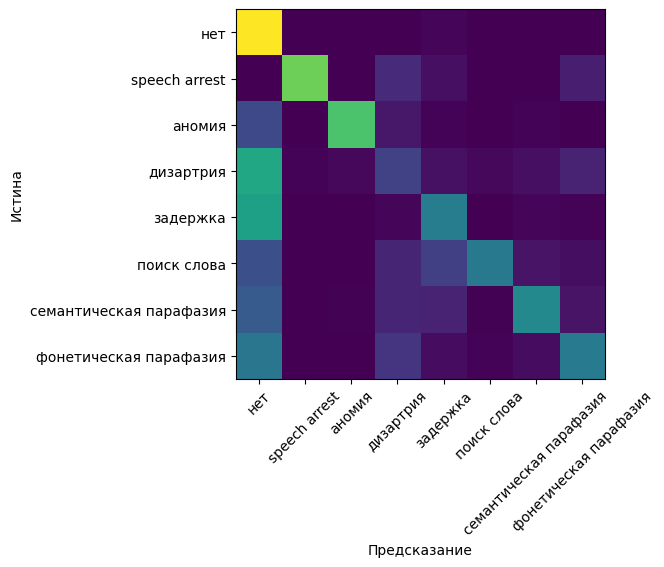

In [59]:
evaluate(ovovn_classifier)


In [60]:
best_max_depth_2 = 0
max_this_f1 = 0
for max_depth in range(1, 11+1):
    ovovn_classifier = OneVsOneVsNeutralClassifier(
        DecisionTreeClassifier(max_depth=max_depth,
                               random_state=SEED),
    DecisionTreeClassifier(random_state=SEED)
    )
    this_f1 = evaluate(ovovn_classifier,
                              supress_print=True,
                              supress_plot=True)
    if max_this_f1 < this_f1:
        max_this_f1 = this_f1
        best_max_depth_2 = max_depth
    print(max_depth, this_f1)


1 0.24793731188674312
2 0.45403260490798913
3 0.516714906677078
4 0.5606342728299714
5 0.5662618410973499
6 0.578499057634817
7 0.5876123147412812
8 0.5710165230203899
9 0.5708505799697857
10 0.563288612833834
11 0.5729702433089636


5it [01:25, 17.04s/it]

Класс			Precision	Recall		F1
нет                     0.95±0.00	0.98±0.00	0.96±0.00
speech arrest           0.79±0.24	0.72±0.27	0.75±0.26
аномия                  0.75±0.10	0.68±0.09	0.71±0.09
дизартрия               0.36±0.09	0.20±0.07	0.26±0.08
задержка                0.68±0.03	0.43±0.03	0.53±0.03
поиск слова             0.55±0.15	0.46±0.16	0.49±0.15
семантическая парафазия 0.60±0.04	0.47±0.12	0.52±0.09
фонетическая парафазия  0.61±0.02	0.39±0.08	0.47±0.06
По всем                 0.66±0.02	0.54±0.01	0.59±0.04


np.float64(0.5876123147412812)

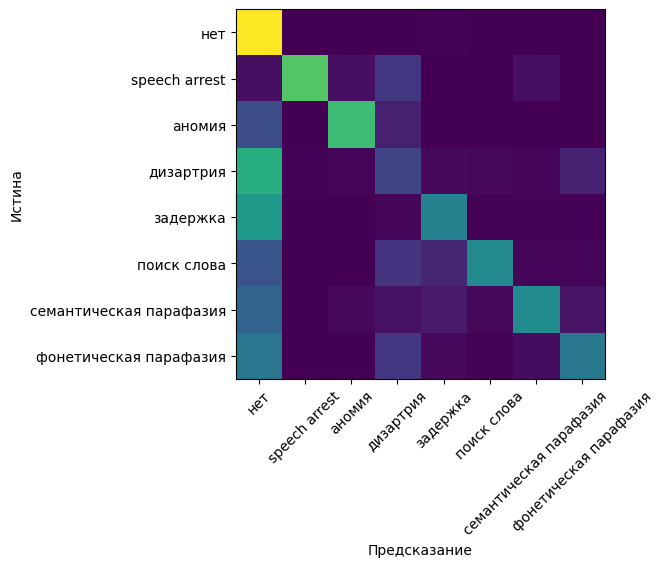

In [61]:
ovovn_classifier = OneVsOneVsNeutralClassifier(
    DecisionTreeClassifier(max_depth=best_max_depth_2, random_state=SEED),
    DecisionTreeClassifier(random_state=SEED)
)
evaluate(ovovn_classifier)


In [198]:
ovovn_classifier.meta_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# ~~Всё то же самое, но уже с транскрипцией~~

In [24]:
dataset = pl.read_csv(
    '../data/processed/train.csv'
    ).drop('StimSite', 'Error_type_annot')\
    .filter(pl.col('Response_transcription_annot').str.len_chars() > 0)


In [25]:
stratified_k_fold = StratifiedKFold(n_splits=5,
                                    random_state=SEED,
                                    shuffle=True)

feature_extractor = FeatureExtractor()

big_X_raw = dataset.drop('error_type_label')
big_y_raw = dataset['error_type_label']

folds_train: list[tuple[pl.DataFrame, pl.Series]] = []
folds_val: list[tuple[pl.DataFrame, pl.Series]] = []

for train_indices, val_indices in stratified_k_fold.split(
                                        np.zeros(dataset.height),
                                        big_y_raw):
    folds_train.append((
        feature_extractor.fit_transform(big_X_raw[train_indices]),
        big_y_raw[train_indices]
    ))
    folds_val.append((
        feature_extractor.transform(big_X_raw[val_indices]),
        big_y_raw[val_indices]
    ))
    assert (folds_train[-1][0].sum_horizontal().sum() * 0) == 0
    assert (folds_train[-1][0].null_count().sum_horizontal().sum()) == 0


1029it [00:11, 87.81it/s] 
382it [00:03, 103.75it/s]
1032it [00:09, 106.01it/s]
414it [00:03, 104.55it/s]
1040it [00:10, 99.65it/s]
406it [00:05, 80.43it/s]
1052it [00:11, 90.56it/s]
362it [00:03, 98.42it/s] 
1024it [00:09, 103.41it/s]
384it [00:03, 106.87it/s]


In [27]:
folds_train[0][0].sample(10)

RT_start,relative_length,relative_length_transcription,Tdelete_normalized_total,Tinsert_normalized_total,Treplace_normalized_total,delete_normalized_total,insert_normalized_total,replace_normalized_total,word_list_distance_0,word_list_distance_1,word_list_distance_2,word_list_frequency_difference_0,word_list_frequency_difference_1,word_list_frequency_difference_2,ruwordnet_graph_distance_0,ruwordnet_graph_distance_1,ruwordnet_graph_distance_2,ruwordnet_n_paths_0,ruwordnet_n_paths_1,ruwordnet_n_paths_2,ruwordnet_levenshtein_distance_0,ruwordnet_levenshtein_distance_1,ruwordnet_levenshtein_distance_2,ruwordnet_graph_distance_min,Tinsert_,Tinsert_т,Tinsert_',Tinsert_ъ,insert_,insert_э,insert_т,insert_о,Tinsert_э,Tinsert_у,Tinsert_/,Tinsert_а,…,replace_т_щ,replace_у_г,replace_у_й,replace_у_н,replace_у_ц,replace_у_ы,replace_ф_п,replace_ф_ц,replace_ф_ш,replace_х_г,replace_ц_р,replace_ч_,replace_ч_н,replace_ч_о,replace_ч_р,replace_ч_щ,replace_ч_ь,replace_ч_э,replace_ш_е,replace_ш_о,replace_ш_с,replace_ш_ч,replace_ш_щ,replace_ы_а,replace_ы_о,replace_ь_,replace_ь_е,replace_ь_т,replace_ь_ы,replace_ю_а,replace_ю_ж,replace_ю_у,replace_я_,replace_я_л,replace_я_р,replace_я_т,replace_я_ь
f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
743.0,1.125,1.25,0.0,0.25,1.0,0.0,0.125,1.0,3,5,5,7.683696,6.305185,4.683696,1,1,1,1,1,1,0.375,0.75,0.75,1,0,1,0,0,0,1,0,0,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1238.0,0.6,2.3,0.2,1.5,0.1,0.4,0.0,0.4,5,5,6,9.752381,0.584963,0.0,1,1,2,2,2,4,0.4,0.5,0.5,1,2,3,3,0,0,0,0,0,0,2,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
896.0,1.5,1.5,0.0,0.5,0.666667,0.0,0.5,0.666667,3,3,3,9.463232,10.270587,10.685625,1,0,1,2,1,1,0.5,0.833333,0.833333,0,0,1,0,0,0,1,1,0,1,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1287.0,0.875,3.0,0.125,2.125,0.25,0.125,0.0,0.0,2,4,4,6.375039,2.169925,1.584963,0,1,2,1,2,4,0.125,0.375,0.625,0,2,2,4,0,0,0,0,0,0,1,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1304.0,1.571429,1.857143,0.0,0.857143,0.285714,0.0,0.571429,0.0,3,3,3,0.0,9.606405,9.606405,0,1,1,1,2,2,0.0,0.714286,0.714286,0,1,1,1,1,1,1,1,1,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1548.0,1.0,2.375,0.125,1.5,0.125,0.125,0.125,0.0,1,1,3,4.087463,12.222191,0.0,0,1,1,1,2,3,0.25,0.5,0.75,0,2,3,1,0,0,0,0,0,0,1,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
901.0,1.428571,3.142857,0.142857,2.285714,0.0,0.142857,0.571429,0.0,2,2,3,2.169925,9.292322,4.169925,0,2,1,1,6,3,0.571429,1.0,1.142857,0,3,3,2,1,1,0,1,0,0,1,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
661.0,1.25,1.625,0.0,0.625,0.75,0.0,0.25,0.625,3,4,4,0.275513,8.292322,6.484967,1,0,1,2,1,2,0.0,0.625,0.75,0,1,1,1,0,0,1,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
823.0,2.0,2.25,0.0,1.25,0.5,0.0,1.0,0.0,4,4,4,0.0,11.083147,6.176256,0,1,1,1,1,1,0.0,1.0,1.25,0,1,1,0,1,1,1,1,1,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
def evaluate_T(model,
               folds_train = folds_train,
               folds_val = folds_val,
               *args, **kwargs):
    return evaluate(model, folds_train, folds_val, *args, **kwargs)


## Бейзлайн

In [31]:
best_macro_F1 = 0.0
best_max_depth = 0
for max_depth in range(1, 13+1):
    score = evaluate_T(DecisionTreeClassifier(max_depth=max_depth, 
                                                random_state=SEED),
                                                supress_plot=True,
                                                supress_print=True)
    if score > best_macro_F1:
        best_macro_F1 = score
        best_max_depth = max_depth


5it [00:00, 16.45it/s]
5it [00:00, 14.53it/s]
5it [00:00, 10.57it/s]
5it [00:00, 13.23it/s]
5it [00:00, 11.57it/s]
5it [00:00, 12.50it/s]
5it [00:00,  8.94it/s]
5it [00:00, 13.74it/s]
5it [00:00, 13.74it/s]
5it [00:00, 12.44it/s]
5it [00:00, 12.59it/s]
5it [00:00, 11.52it/s]
5it [00:00, 12.17it/s]


In [32]:
best_max_depth

12

5it [00:00,  7.60it/s]

Класс			Precision	Recall		F1
нет                     0.17±0.07	0.16±0.08	0.16±0.07
аномия                  0.82±0.11	0.77±0.09	0.79±0.08
дизартрия               0.48±0.05	0.44±0.04	0.46±0.01
задержка                0.80±0.02	0.82±0.03	0.81±0.02
поиск слова             0.54±0.12	0.46±0.15	0.48±0.11
семантическая парафазия 0.42±0.14	0.42±0.19	0.42±0.16
фонетическая парафазия  0.59±0.02	0.63±0.05	0.60±0.02
По всем                 0.55±0.02	0.53±0.04	0.53±0.04


np.float64(0.5319059685210672)

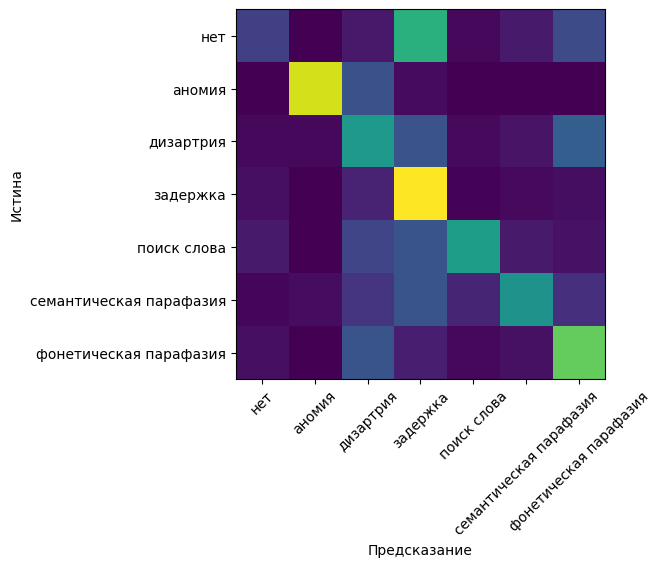

In [33]:
evaluate_T(DecisionTreeClassifier(max_depth=12, 
                                    random_state=SEED))

## Простые решения

5it [00:05,  1.08s/it]

Класс			Precision	Recall		F1
нет                     0.24±0.04	0.14±0.05	0.17±0.05
аномия                  0.88±0.10	0.82±0.13	0.84±0.07
дизартрия               0.58±0.08	0.45±0.07	0.51±0.07
задержка                0.76±0.02	0.93±0.02	0.83±0.02
поиск слова             0.69±0.09	0.50±0.14	0.57±0.11
семантическая парафазия 0.79±0.12	0.31±0.10	0.44±0.12
фонетическая парафазия  0.66±0.04	0.66±0.06	0.65±0.03
По всем                 0.66±0.02	0.54±0.02	0.57±0.03


np.float64(0.5730461871553787)

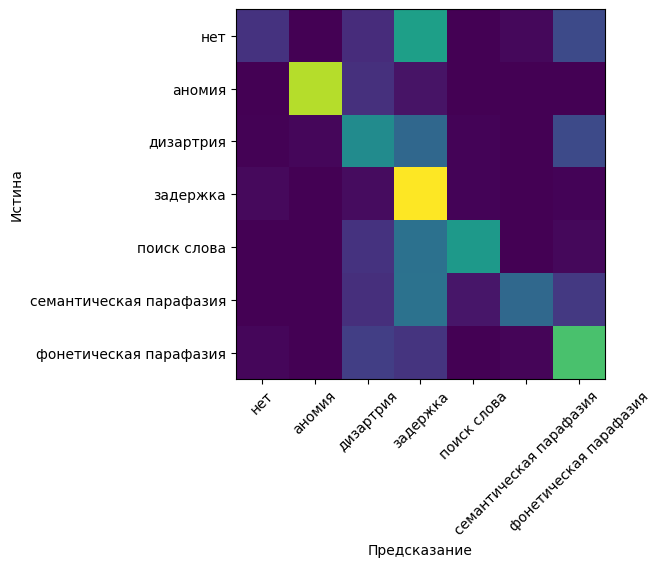

In [34]:
evaluate_T(RandomForestClassifier(random_state=SEED))


5it [02:17, 27.45s/it]

Класс			Precision	Recall		F1
нет                     0.03±0.07	0.02±0.04	0.03±0.05
аномия                  0.90±0.09	0.82±0.13	0.85±0.07
дизартрия               0.65±0.03	0.55±0.06	0.59±0.03
задержка                0.82±0.01	0.93±0.03	0.87±0.01
поиск слова             0.73±0.17	0.52±0.13	0.58±0.07
семантическая парафазия 0.62±0.15	0.48±0.13	0.53±0.11
фонетическая парафазия  0.69±0.03	0.76±0.04	0.72±0.02
По всем                 0.64±0.02	0.58±0.02	0.60±0.02


np.float64(0.5960871806451691)

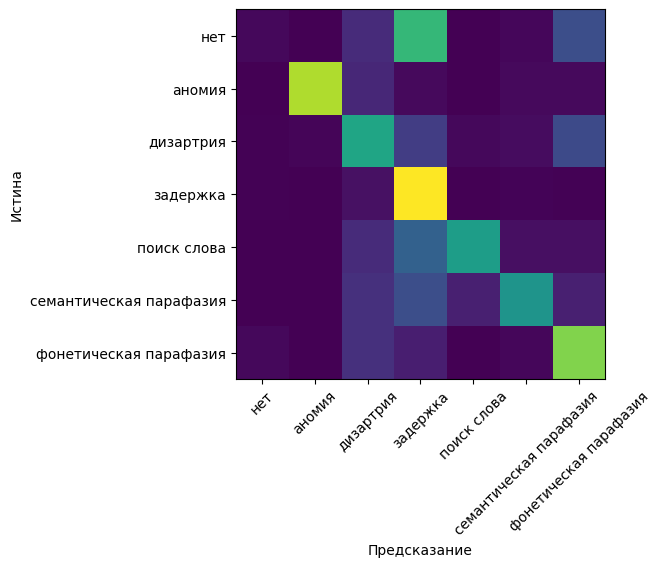

In [35]:
evaluate_T(catboost.CatBoostClassifier(task_type='GPU',
                                    devices='0',
                                    random_state=SEED,
                                    silent=True))

## Подбор признаков для каждого 1v1vN

In [36]:
column_group_names = ['RT_start',
                      'relative_length',
                      'relative_length_transcription',
                      '^[^T].+_normalized_total$',
                      '^T.+_normalized_total$',
                      '^word_list_.+$',
                      '^ruwordnet_.+$',
                      '^[^T].+_[а-яё ]$',
                      '^T.+_[а-яё ]$']


In [43]:
column_groups_to_use: list[tuple[str,...]] = list(
                                    get_powerset(column_group_names))

In [44]:
combinations_1v1vN_ = set(itertools.permutations([1,1,0,0,0,0,0]))

In [45]:
combinations_1v1vN = set()
for combination in combinations_1v1vN_:
    combination = list(combination)
    # обработка отсуствия speech arrest
    combination = combination[:1] + [0] + combination[1:]
    combination[combination.index(1)] = -1
    combinations_1v1vN.add(tuple(combination))

In [49]:
f1s_for_column_groups_1v1vn = np.zeros((28, 512, 3))
for i, combination in tqdm(enumerate(combinations_1v1vN)):
    # print(i, combination)
    for j, column_groups in tqdm(enumerate(column_groups_to_use)):
        # print(j, column_groups)
        f1s_for_column_groups_1v1vn[i, j] = evaluate_T(
                                DecisionTreeClassifier(max_depth=12,
                                                    random_state=SEED),
                                output_separate_f1s=True,
                                include_features=list(column_groups),
                                merge_classes=list(combination),
                                supress_print=True,
                                supress_plot=True)
        # print(*f1s_for_column_groups_1v1vn[i, j].round(2))
    print(*f1s_for_column_groups_1v1vn.max(axis=(0,1)), '====')


512it [02:12,  3.88it/s]
1it [02:12, 132.08s/it]

0.8741736694677871 0.8821816875150796 0.44897644353454896 ====


512it [02:15,  3.77it/s]
2it [04:27, 134.33s/it]

0.8741736694677871 0.8821816875150796 0.6066475279106858 ====


512it [02:10,  3.91it/s]
3it [06:38, 132.73s/it]

0.8741736694677871 0.8821816875150796 0.6066475279106858 ====


512it [02:39,  3.20it/s]
4it [09:18, 143.46s/it]

0.8741736694677871 0.9819215974660505 0.6257438838513008 ====


512it [01:52,  4.56it/s]
5it [11:10, 132.20s/it]

0.8741736694677871 0.9819215974660505 0.6257438838513008 ====


512it [02:00,  4.24it/s]
6it [13:11, 128.36s/it]

0.8741736694677871 0.9819215974660505 0.6257438838513008 ====


512it [01:59,  4.29it/s]
7it [15:11, 125.42s/it]

0.8741736694677871 0.9819215974660505 0.6380579791725303 ====


512it [02:05,  4.07it/s]
8it [17:17, 125.55s/it]

0.8741736694677871 0.9819215974660505 0.6380579791725303 ====


512it [02:11,  3.88it/s]
9it [19:28, 127.52s/it]

0.8741736694677871 0.9819215974660505 0.6380579791725303 ====


512it [01:59,  4.29it/s]
10it [21:28, 125.04s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [02:07,  4.03it/s]
11it [23:35, 125.68s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [02:10,  3.91it/s]
12it [25:46, 127.23s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [02:08,  3.98it/s]
13it [27:54, 127.65s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [01:56,  4.39it/s]
14it [29:51, 124.28s/it]

0.8788888888888889 0.9819215974660505 0.6684192524800426 ====


512it [01:49,  4.68it/s]
15it [31:40, 119.77s/it]

0.8788888888888889 0.9819215974660505 0.8267290712621722 ====


512it [02:01,  4.22it/s]
16it [33:42, 120.26s/it]

0.8788888888888889 0.9819215974660505 0.8267290712621722 ====


512it [02:39,  3.21it/s]
17it [36:21, 132.01s/it]

0.8788888888888889 0.9819215974660505 0.858421052631579 ====


512it [02:00,  4.24it/s]
18it [38:22, 128.65s/it]

0.8788888888888889 0.9819215974660505 0.858421052631579 ====


512it [01:50,  4.62it/s]
19it [40:13, 123.28s/it]

0.8788888888888889 0.9819215974660505 0.858421052631579 ====


512it [01:46,  4.80it/s]
20it [41:59, 118.31s/it]

0.9080952380952381 0.9819215974660505 0.858421052631579 ====


512it [02:38,  3.22it/s]
21it [44:38, 127.56s/it]

0.9080952380952381 0.9819215974660505 0.858421052631579 ====


In [50]:
joblib.dump(f1s_for_column_groups_1v1vn, '1v1vNT_12.joblib.xz', 9)

['1v1vNT_12.joblib.xz']

In [55]:
f1s_for_column_groups_1v1vn_macro = f1s_for_column_groups_1v1vn\
                                             .mean(axis=2)[:21]

In [57]:
np.array(list(combinations_1v1vN))[
np.argsort(f1s_for_column_groups_1v1vn_macro.max(axis=1))]\
    .nonzero()[1]\
    .reshape(-1, 2)

array([[0, 3],
       [0, 5],
       [0, 6],
       [3, 6],
       [0, 7],
       [0, 4],
       [3, 5],
       [0, 2],
       [3, 4],
       [6, 7],
       [3, 7],
       [5, 7],
       [4, 6],
       [5, 6],
       [4, 7],
       [2, 3],
       [4, 5],
       [2, 6],
       [2, 7],
       [2, 5],
       [2, 4]])

In [58]:
np.set_printoptions(linewidth=np.inf)

In [59]:
class_pairs_and_features_all = np.hstack(
[
        np.array(list(combinations_1v1vN))\
            .nonzero()[1]\
            .reshape(-1, 2),
            
            np.array(column_groups_to_use, dtype=object)[:, np.newaxis]\
    [f1s_for_column_groups_1v1vn_macro.argmax(axis=1)],]
    )

In [60]:
class_pairs_and_features_all

array([[2, 3, ('RT_start', 'relative_length_transcription', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$')],
       [4, 5, ()],
       [0, 3, ()],
       [2, 5, ('RT_start', 'relative_length_transcription', '^T.+_normalized_total$', '^word_list_.+$', '^[^T].+_[а-яё ]$')],
       [4, 6, ('relative_length', 'relative_length_transcription', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [3, 6, ('relative_length', '^T.+_normalized_total$', '^ruwordnet_.+$', '^[^T].+_[а-яё ]$')],
       [0, 7, ('RT_start', 'relative_length', '^[^T].+_normalized_total$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [3, 5, ()],
       [0, 6, ('relative_length', 'relative_length_transcription', '^word_list_.+$', '^ruwordnet_.+$')],
       [2, 7, ('RT_start', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [2, 6, ('RT_start', 'relative_length',

In [61]:
class_pairs_and_features_all = class_pairs_and_features_all[
    np.lexsort((class_pairs_and_features_all[:, 1],
                class_pairs_and_features_all[:, 0]))
]

In [62]:
class_pairs_and_features_all

array([[0, 2, ()],
       [0, 3, ()],
       [0, 4, ()],
       [0, 5, ('RT_start', 'relative_length', 'relative_length_transcription', '^T.+_normalized_total$', '^[^T].+_[а-яё ]$')],
       [0, 6, ('relative_length', 'relative_length_transcription', '^word_list_.+$', '^ruwordnet_.+$')],
       [0, 7, ('RT_start', 'relative_length', '^[^T].+_normalized_total$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [2, 3, ('RT_start', 'relative_length_transcription', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$')],
       [2, 4, ()],
       [2, 5, ('RT_start', 'relative_length_transcription', '^T.+_normalized_total$', '^word_list_.+$', '^[^T].+_[а-яё ]$')],
       [2, 6, ('RT_start', 'relative_length', 'relative_length_transcription', '^[^T].+_normalized_total$', '^word_list_.+$', '^T.+_[а-яё ]$')],
       [2, 7, ('RT_start', '^[^T].+_normalized_total$', '^T.+_normalized_total$', '^ruwordnet_.+$', '^[^T].+_[а-яё ]$', '^T.+_[а-яё ]$')],
       [3, 4, ()],
       [3, 5, 

In [63]:
class_pairs_and_features_ = pl.DataFrame(class_pairs_and_features_all[:,0:2].astype(np.int8)).hstack(
    pl.DataFrame(class_pairs_and_features_all[:,2],
                 schema=['include_features'])
).with_columns(
    pl.col('include_features')\
        .map_elements(lambda x: str('\uE000'.join(x)),
                      return_dtype=pl.String)
).rename({'column_0': 'class_1', 'column_1': 'class_2'})


In [64]:
class_pairs_and_features_

class_1,class_2,include_features
i8,i8,str
0,2,""""""
0,3,""""""
0,4,""""""
0,5,"""RT_startrelative_lengthrelat…"
0,6,"""relative_lengthrelative_lengt…"
…,…,…
4,6,"""relative_lengthrelative_lengt…"
4,7,""""""
5,6,""""""


In [65]:
class_pairs_and_features_.write_csv('../data/models/'
                                    'class_pairs_and_featuresT.csv')


## 1 vs 1 с нейтральным классом

In [76]:
ovovn_classifier_T = OneVsOneVsNeutralClassifier(
                        DecisionTreeClassifier(max_depth=12, 
                                            random_state=SEED),
                        DecisionTreeClassifier(random_state=SEED),
                        class_pairs_and_features_path='../data/models/'
                                    'class_pairs_and_featuresT.csv'
    )

5it [00:09,  1.84s/it]

Класс			Precision	Recall		F1
нет                     0.16±0.04	0.27±0.09	0.19±0.06
аномия                  0.83±0.14	0.72±0.12	0.77±0.12
дизартрия               0.53±0.05	0.61±0.08	0.56±0.02
задержка                0.85±0.03	0.80±0.02	0.83±0.02
поиск слова             0.75±0.07	0.53±0.24	0.59±0.19
семантическая парафазия 0.50±0.16	0.42±0.07	0.44±0.08
фонетическая парафазия  0.66±0.07	0.57±0.04	0.61±0.05
По всем                 0.61±0.04	0.56±0.05	0.57±0.05


np.float64(0.5697565583332951)

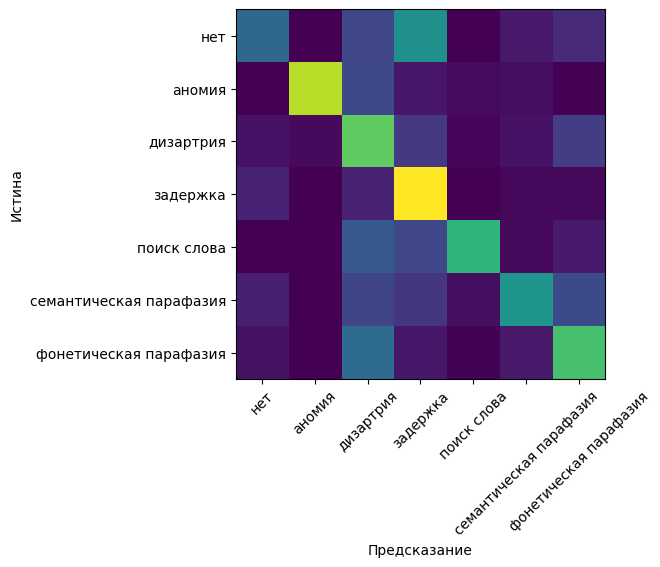

In [77]:
evaluate_T(ovovn_classifier_T)

In [79]:
for max_depth in range(1, 14):
    ovovn_classifier_T = OneVsOneVsNeutralClassifier(
                        DecisionTreeClassifier(max_depth=max_depth, 
                                            random_state=SEED),
                        DecisionTreeClassifier(random_state=SEED),
                        class_pairs_and_features_path='../data/models/'
                                    'class_pairs_and_featuresT.csv'
        )
    print(max_depth,
          evaluate_T(ovovn_classifier_T,
                     supress_print = True,
                     supress_plot = True))


1 0.32840349105797795
2 0.45145725208160065
3 0.5460282612809564
4 0.546957008202296
5 0.5684825901129991
6 0.582323754146648
7 0.5812767698650254
8 0.5593972527316075
9 0.565802510327814
10 0.538673714446493
11 0.5521121755174531
12 0.5697565583332951
13 0.5269410196567147


In [80]:
ovovn_classifier_T = OneVsOneVsNeutralClassifier(
                        DecisionTreeClassifier(max_depth=6, 
                                            random_state=SEED),
                        DecisionTreeClassifier(random_state=SEED),
                        class_pairs_and_features_path='../data/models/'
                                    'class_pairs_and_featuresT.csv'
        )

5it [00:08,  1.62s/it]

Класс			Precision	Recall		F1
нет                     0.19±0.10	0.15±0.08	0.15±0.06
аномия                  0.87±0.13	0.80±0.10	0.82±0.08
дизартрия               0.54±0.06	0.53±0.05	0.53±0.05
задержка                0.84±0.01	0.85±0.05	0.84±0.03
поиск слова             0.56±0.09	0.62±0.19	0.58±0.13
семантическая парафазия 0.51±0.03	0.44±0.08	0.47±0.04
фонетическая парафазия  0.69±0.04	0.68±0.08	0.68±0.06
По всем                 0.60±0.04	0.58±0.03	0.58±0.03


np.float64(0.582323754146648)

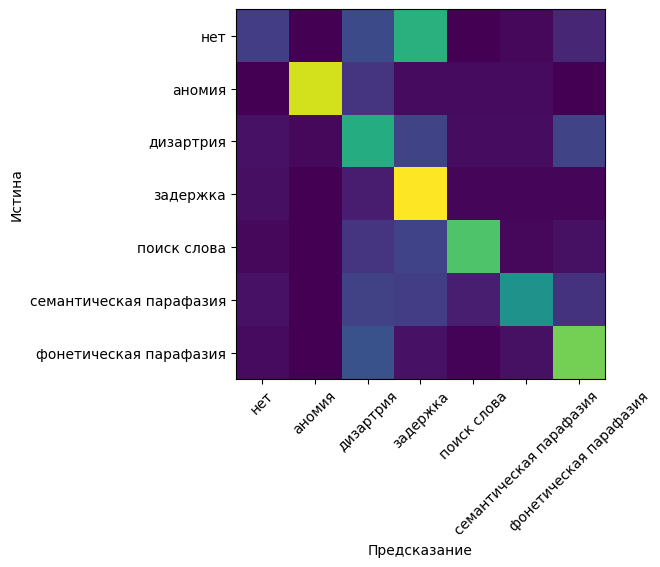

In [81]:
evaluate_T(ovovn_classifier_T)